# Banking77: PyTorch Lightning для семейства RNN-моделей

## Структура ноутбука

1. Проверка `PyTorch + Lightning + CUDA` runtime.
2. Загрузка snapshot `Banking77` и очистка данных от дубликатов и пересечений между split'ами.
3. Описание протокола `train / val / test` и связи экспериментов с задачей маршрутизации обращений.
4. Единый конфигурационный блок для baseline и экспериментальных серий.
5. `LightningDataModule` для входного пайплайна и `LightningModule` для RNN-моделей.
6. Базовый Lightning-блок для 8 RNN-конфигураций.
7. Серии экспериментов A-E: входной пайплайн, архитектура, регуляризация, оптимизация и финальные связки.
8. Сравнение лучшей классической модели из `02`, лучшей untuned RNN и лучшей tuned RNN.
9. Анализ ошибок лучшей tuned-модели, сохранение артефактов и итоговый вывод.

Ноутбук полностью self-contained и использует тот же протокол очистки данных и разбиения, что и предыдущие этапы проекта. Это позволяет корректно сравнивать нейросетевые модели с классическими baseline-решениями.


In [1]:
import ctypes
import json
import os
import random
import re
import shutil
import subprocess
import time
from collections import Counter
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from datasets import load_dataset, load_from_disk
from lightning.pytorch import LightningDataModule, LightningModule, Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

PROJECT_ROOT = Path(r"/home/sukuna/Projects/RNN")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
REPORTS_DIR = ARTIFACTS_DIR / "reports"
LIGHTNING_LOGS_DIR = ARTIFACTS_DIR / "lightning_logs"
LIGHTNING_CKPT_DIR = MODELS_DIR / "lightning_ckpts"
SNAPSHOT_DIR = RAW_DATA_DIR / "banking77_snapshot"
LABEL_MAPPING_PATH = RAW_DATA_DIR / "label_mapping.json"

DATASET_NAME = "PolyAI/banking77"
DATASET_REVISION = "refs/pr/6"
RANDOM_STATE = 42
VAL_SIZE = 0.2
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
WHITESPACE_RE = re.compile(r"\s+")
CUDA_RELEASE_RE = re.compile(r"release\s+(\d+)\.(\d+)", re.IGNORECASE)
DRIVER_RELEASE_RE = re.compile(r"(\d+)\.(\d+)\.(\d+)")
DEVICE = torch.device("cuda")


/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Проверка PyTorch, Lightning и GPU

Ниже выполняется проверка среды исполнения. Для этого ноутбука важно, чтобы одновременно были доступны:

- `torch` с CUDA;
- `lightning.pytorch`;
- `torchmetrics`;
- реальное GPU-устройство внутри текущего kernel.

Также делается небольшой smoke test на рекуррентном слое, чтобы до запуска всей серии экспериментов убедиться, что среда действительно рабочая.


In [2]:
def run_command(command: list[str]) -> str:
    try:
        completed = subprocess.run(command, check=False, capture_output=True, text=True)
    except FileNotFoundError:
        return ""
    return completed.stdout.strip() if completed.returncode == 0 else ""


def decode_cuda_version(raw_version: int | None) -> str | None:
    if raw_version in (None, 0):
        return None
    major = raw_version // 1000
    minor = (raw_version % 1000) // 10
    return f"{major}.{minor}"


def find_host_driver_library() -> str | None:
    candidates = [
        Path("/run/host/usr/lib/libcuda.so.1"),
        Path("/run/host/usr/lib/libcuda.so"),
        Path("/usr/lib/x86_64-linux-gnu/libcuda.so.1"),
        Path("/usr/lib64/libcuda.so.1"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return None


def preload_nvidia_driver_libraries() -> dict:
    driver_library_path = find_host_driver_library()
    management_library_path = None
    preload_error = None

    if driver_library_path is None:
        return {
            "driver_library_path": None,
            "management_library_path": None,
            "preload_error": "libcuda.so.1 не найден в ожидаемых путях.",
        }

    try:
        ctypes.CDLL(driver_library_path, mode=ctypes.RTLD_GLOBAL)
        management_candidate = Path("/run/host/usr/lib/libnvidia-ml.so.1")
        if management_candidate.exists():
            ctypes.CDLL(str(management_candidate), mode=ctypes.RTLD_GLOBAL)
            management_library_path = str(management_candidate)
    except OSError as exc:
        preload_error = f"{type(exc).__name__}: {exc}"

    return {
        "driver_library_path": driver_library_path,
        "management_library_path": management_library_path,
        "preload_error": preload_error,
    }


def detect_cuda_runtime() -> dict:
    nvcc_candidates = [
        Path(os.environ.get("CUDA_PATH", "")) / "bin" / "nvcc",
        Path("/opt/cuda/bin/nvcc"),
        Path("/usr/local/cuda/bin/nvcc"),
    ]
    nvcc_path = next((candidate for candidate in nvcc_candidates if candidate.exists()), None)

    cuda_major = None
    cuda_minor = None
    if nvcc_path is not None:
        nvcc_output = run_command([str(nvcc_path), "--version"])
        match = CUDA_RELEASE_RE.search(nvcc_output)
        if match:
            cuda_major = int(match.group(1))
            cuda_minor = int(match.group(2))

    driver_major = None
    driver_version_text = None
    driver_version_path = Path("/proc/driver/nvidia/version")
    if driver_version_path.exists():
        driver_version_text = driver_version_path.read_text(encoding="utf-8")
        match = DRIVER_RELEASE_RE.search(driver_version_text)
        if match:
            driver_major = int(match.group(1))

    has_nvidia_devices = any(Path(path).exists() for path in ("/dev/nvidiactl", "/dev/nvidia0"))

    return {
        "cuda_major": cuda_major,
        "cuda_minor": cuda_minor,
        "driver_major": driver_major,
        "driver_version_text": driver_version_text,
        "nvcc_path": str(nvcc_path) if nvcc_path is not None else None,
        "has_nvidia_devices": has_nvidia_devices,
        "nvidia_smi": run_command(["nvidia-smi"]),
        **preload_nvidia_driver_libraries(),
    }


def build_runtime_error(runtime: dict, extra_message: str | None = None, versions: dict | None = None) -> str:
    lines = [
        "PyTorch Lightning runtime недоступен для выполнения этого ноутбука.",
        "",
        "Диагностика окружения:",
        f"- CUDA toolkit по nvcc: {runtime['cuda_major']}.{runtime['cuda_minor']}" if runtime['cuda_major'] is not None else "- CUDA toolkit по nvcc: не определён",
        f"- kernel-драйвер NVIDIA: {runtime['driver_major']}" if runtime['driver_major'] is not None else "- kernel-драйвер NVIDIA: не определён",
        f"- устройства /dev/nvidia*: {'да' if runtime['has_nvidia_devices'] else 'нет'}",
        f"- nvidia-smi: {'доступен' if runtime['nvidia_smi'] else 'недоступен'}",
        f"- путь к libcuda.so.1: {runtime['driver_library_path'] or 'не найден'}",
        f"- путь к libnvidia-ml.so.1: {runtime['management_library_path'] or 'не найден'}",
    ]
    if versions is not None:
        lines.extend(
            [
                f"- torch: {versions['torch_version']}",
                f"- lightning: {versions['lightning_version']}",
                f"- torchmetrics: {versions['torchmetrics_version']}",
                f"- torch CUDA build: {versions['torch_cuda_build']}",
                f"- torch.cuda.is_available(): {versions['cuda_available']}",
                f"- число GPU: {versions['device_count']}",
                f"- имя устройства: {versions['device_name'] or 'не определено'}",
            ]
        )
    if extra_message:
        lines.extend(["", "Подробность ошибки:", f"- {extra_message}"])
    return "\n".join(lines)


def assert_lightning_runtime() -> dict:
    runtime = detect_cuda_runtime()

    try:
        import lightning
        import lightning.pytorch as pl
        import torchmetrics
    except Exception as exc:
        raise RuntimeError(build_runtime_error(runtime, f"{type(exc).__name__}: {exc}")) from None

    versions = {
        "torch_version": torch.__version__,
        "lightning_version": lightning.__version__,
        "torchmetrics_version": torchmetrics.__version__,
        "torch_cuda_build": torch.version.cuda,
        "cuda_available": bool(torch.cuda.is_available()),
        "device_count": int(torch.cuda.device_count()) if torch.cuda.is_available() else 0,
        "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() and torch.cuda.device_count() > 0 else None,
    }

    if not versions["cuda_available"] or versions["device_count"] < 1:
        raise RuntimeError(build_runtime_error(runtime, None, versions))

    try:
        embedding = nn.Embedding(32, 8).to(DEVICE)
        recurrent = nn.GRU(input_size=8, hidden_size=12, batch_first=True).to(DEVICE)
        sample_ids = torch.tensor([[1, 2, 3, 0], [4, 5, 0, 0]], dtype=torch.long, device=DEVICE)
        lengths = torch.tensor([3, 2], dtype=torch.long)
        embedded = embedding(sample_ids)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = recurrent(packed)
    except Exception as exc:
        raise RuntimeError(build_runtime_error(runtime, f"{type(exc).__name__}: {exc}", versions)) from None

    return {
        **runtime,
        **versions,
        "smoke_hidden_shape": tuple(int(x) for x in hidden.shape),
    }


In [3]:
runtime = assert_lightning_runtime()
display(Markdown("### Результат проверки окружения"))
display(pd.DataFrame([runtime]))


### Результат проверки окружения

,cuda_major,cuda_minor,driver_major,driver_version_text,nvcc_path,has_nvidia_devices,nvidia_smi,driver_library_path,management_library_path,preload_error,torch_version,lightning_version,torchmetrics_version,torch_cuda_build,cuda_available,device_count,device_name,smoke_hidden_shape
0,13,1,None,NVRM version: NVIDIA UNIX Open Kernel Module for x86_64 590.48.01 Release Build (root@) \nGCC version: gcc version 15.2.1 20260209 (GCC) \n,/opt/cuda/bin/nvcc,True,,/run/host/usr/lib/libcuda.so.1,/run/host/usr/lib/libnvidia-ml.so.1,None,2.11.0+cu130,2.6.1,1.9.0,13.0,True,1,NVIDIA GeForce RTX 5070 Ti,"(1, 2, 12)"


## Загрузка данных и подготовка выборок

Для воспроизводимости используется тот же snapshot `Banking77`, что и на предыдущих этапах. Ноутбук повторяет уже выбранный протокол очистки данных:

- удаление точных дубликатов внутри `official_train` и `official_test`;
- удаление пересечений между `official_train` и `official_test` по нормализованному тексту;
- построение рабочего `train / val / test` только после очистки.

Это важно, потому что экспериментальная серия будет большой, и нужно быть уверенными, что улучшения качества не возникают из-за утечки данных между выборками.


In [4]:
def load_banking77_snapshot(force_refresh: bool = False):
    RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    LIGHTNING_LOGS_DIR.mkdir(parents=True, exist_ok=True)
    LIGHTNING_CKPT_DIR.mkdir(parents=True, exist_ok=True)

    if SNAPSHOT_DIR.exists() and not force_refresh:
        return load_from_disk(str(SNAPSHOT_DIR))

    dataset = load_dataset(DATASET_NAME, revision=DATASET_REVISION, cache_dir=str(RAW_DATA_DIR / "hf_cache"))
    dataset.save_to_disk(str(SNAPSHOT_DIR))
    label_mapping = {i: label for i, label in enumerate(dataset["train"].features["label"].names)}
    LABEL_MAPPING_PATH.write_text(json.dumps(label_mapping, indent=2, ensure_ascii=False), encoding="utf-8")
    return dataset


def normalize_text(text: str) -> str:
    text = text if isinstance(text, str) else ""
    text = text.strip().lower()
    text = WHITESPACE_RE.sub(" ", text)
    return text


def split_to_frame(dataset, split_name: str) -> pd.DataFrame:
    label_names = list(dataset["train"].features["label"].names)
    frame = dataset[split_name].to_pandas()[["text", "label"]].copy()
    frame["label_name"] = frame["label"].map(lambda idx: label_names[int(idx)])
    frame["text_normalized"] = frame["text"].map(normalize_text)
    frame["char_length"] = frame["text_normalized"].str.len()
    frame["word_length"] = frame["text_normalized"].str.split().str.len()
    return frame


def deduplicate_exact_texts(frame: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    deduplicated = frame.drop_duplicates(subset=["text_normalized", "label"], keep="first").reset_index(drop=True)
    removed_count = int(len(frame) - len(deduplicated))
    return deduplicated, removed_count


def remove_train_test_text_overlap(train_frame: pd.DataFrame, test_frame: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    test_texts = set(test_frame["text_normalized"].tolist())
    overlap_mask = train_frame["text_normalized"].isin(test_texts)
    cleaned_train = train_frame.loc[~overlap_mask].reset_index(drop=True)
    removed_count = int(overlap_mask.sum())
    return cleaned_train, removed_count


def build_experiment_splits(dataset):
    official_train_raw = split_to_frame(dataset, "train")
    official_test_raw = split_to_frame(dataset, "test")

    official_train_dedup, removed_train_duplicates = deduplicate_exact_texts(official_train_raw)
    official_test_dedup, removed_test_duplicates = deduplicate_exact_texts(official_test_raw)
    official_train_clean, removed_train_test_overlap = remove_train_test_text_overlap(
        official_train_dedup,
        official_test_dedup,
    )

    train_df, val_df = train_test_split(
        official_train_clean,
        test_size=VAL_SIZE,
        random_state=RANDOM_STATE,
        stratify=official_train_clean["label"],
    )

    split_frames = {
        "official_train": official_train_clean.reset_index(drop=True),
        "official_test": official_test_dedup.reset_index(drop=True),
        "train": train_df.reset_index(drop=True),
        "val": val_df.reset_index(drop=True),
        "test": official_test_dedup.reset_index(drop=True),
    }
    raw_split_frames = {
        "official_train_raw": official_train_raw.reset_index(drop=True),
        "official_test_raw": official_test_raw.reset_index(drop=True),
    }
    cleaning_report_df = pd.DataFrame(
        [
            {
                "Шаг очистки": "Удаление точных дубликатов в official_train",
                "Удалено строк": removed_train_duplicates,
            },
            {
                "Шаг очистки": "Удаление точных дубликатов в official_test",
                "Удалено строк": removed_test_duplicates,
            },
            {
                "Шаг очистки": "Удаление пересечений official_train с official_test",
                "Удалено строк": removed_train_test_overlap,
            },
        ]
    )
    return split_frames, raw_split_frames, cleaning_report_df


def summarize_splits(split_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for split_name, frame in split_frames.items():
        rows.append(
            {
                "split": split_name,
                "rows": int(len(frame)),
                "unique_labels": int(frame["label"].nunique()),
                "missing_texts": int(frame["text"].isna().sum()),
                "missing_labels": int(frame["label"].isna().sum()),
                "mean_char_length": round(float(frame["char_length"].mean()), 2),
                "mean_word_length": round(float(frame["word_length"].mean()), 2),
            }
        )
    return pd.DataFrame(rows).sort_values("split").reset_index(drop=True)


def load_label_names(dataset) -> list[str]:
    label_mapping = {i: label for i, label in enumerate(dataset["train"].features["label"].names)}
    LABEL_MAPPING_PATH.write_text(json.dumps(label_mapping, indent=2, ensure_ascii=False), encoding="utf-8")
    return [label_mapping[i] for i in sorted(label_mapping)]


def build_within_split_duplicate_report(split_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for split_name, frame in split_frames.items():
        duplicate_mask = frame["text_normalized"].duplicated(keep=False)
        duplicate_rows = frame.loc[duplicate_mask].copy()
        rows.append(
            {
                "split": split_name,
                "rows": int(len(frame)),
                "unique_normalized_texts": int(frame["text_normalized"].nunique()),
                "duplicate_rows": int(duplicate_mask.sum()),
                "duplicate_unique_texts": int(duplicate_rows["text_normalized"].nunique()) if not duplicate_rows.empty else 0,
            }
        )
    return pd.DataFrame(rows).sort_values("split").reset_index(drop=True)


def build_between_split_overlap_report(split_frames: dict[str, pd.DataFrame], split_names: list[str]) -> pd.DataFrame:
    rows = []
    for idx, split_a in enumerate(split_names):
        texts_a = set(split_frames[split_a]["text_normalized"].tolist())
        for split_b in split_names[idx + 1:]:
            texts_b = set(split_frames[split_b]["text_normalized"].tolist())
            rows.append(
                {
                    "split_a": split_a,
                    "split_b": split_b,
                    "shared_normalized_texts": int(len(texts_a & texts_b)),
                }
            )
    return (
        pd.DataFrame(rows)
        .sort_values(["shared_normalized_texts", "split_a", "split_b"], ascending=[False, True, True])
        .reset_index(drop=True)
    )


In [5]:
dataset = load_banking77_snapshot()
label_names = load_label_names(dataset)
NUM_CLASSES = len(label_names)
official_counts = {split_name: len(split) for split_name, split in dataset.items()}
split_frames, raw_split_frames, cleaning_report_df = build_experiment_splits(dataset)
raw_split_summary = summarize_splits(raw_split_frames)
split_summary = summarize_splits(split_frames)
raw_within_split_duplicates_df = build_within_split_duplicate_report(raw_split_frames)
clean_within_split_duplicates_df = build_within_split_duplicate_report(split_frames)
between_split_overlap_df = build_between_split_overlap_report(
    split_frames,
    ["official_train", "official_test", "train", "val", "test"],
)

display(Markdown("### Официальные размеры датасета"))
display(pd.DataFrame([official_counts]))


### Официальные размеры датасета

,train,test
0,10003,3080


In [6]:
display(Markdown("### Отчёт по очистке данных"))
display(cleaning_report_df)

display(Markdown("### Сводка по необработанным official split'ам"))
display(raw_split_summary)

display(Markdown("### Сводка по рабочим split'ам после очистки"))
display(split_summary)

display(Markdown("### Дубликаты внутри raw split'ов"))
display(raw_within_split_duplicates_df)

display(Markdown("### Дубликаты внутри рабочих split'ов"))
display(clean_within_split_duplicates_df)

display(Markdown("### Пересечения между split'ами по нормализованному тексту"))
display(between_split_overlap_df)


### Отчёт по очистке данных

,Шаг очистки,Удалено строк
0,Удаление точных дубликатов в official_train,4
1,Удаление точных дубликатов в official_test,1
2,Удаление пересечений official_train с official_test,7


### Сводка по необработанным official split'ам

,split,rows,unique_labels,missing_texts,missing_labels,mean_char_length,mean_word_length
0,official_test_raw,3080,77,0,0,54.19,10.95
1,official_train_raw,10003,77,0,0,59.41,11.95


### Сводка по рабочим split'ам после очистки

...

,split,rows,unique_normalized_texts,duplicate_rows,duplicate_unique_texts
0,official_test_raw,3080,3079,2,1
1,official_train_raw,10003,9999,8,4


### Дубликаты внутри рабочих split'ов

,split,rows,unique_normalized_texts,duplicate_rows,duplicate_unique_texts
0,official_test,3079,3079,0,0
1,official_train,9992,9992,0,0
2,test,3079,3079,0,0
3,train,7993,7993,0,0
4,val,1999,1999,0,0


### Пересечения между split'ами по нормализованному тексту

,split_a,split_b,shared_normalized_texts
0,official_train,train,7993
1,official_test,test,3079
2,official_train,val,1999
3,official_test,train,0
4,official_test,val,0
5,official_train,official_test,0
6,official_train,test,0
7,train,test,0
8,train,val,0
9,val,test,0


## Протокол эксперимента и место Lightning-блока в проекте

Цель этого ноутбука — перейти от базового нейросетевого baseline к более систематическому исследованию семейства RNN-моделей. Все эксперименты ниже построены так, чтобы отвечать на прикладной вопрос дипломного проекта: можно ли улучшить качество автоматической классификации и маршрутизации банковских обращений за счёт более сильной рекуррентной архитектуры и аккуратной настройки обучения.

Ключевые правила остаются такими:

- `train` используется только для обучения;
- `val` используется для выбора лучшей конфигурации;
- `test` считается для всех запусков как справочная контрольная метрика, но победитель выбирается только по `val macro-F1`, затем по `val accuracy`.

`PyTorch Lightning` используется здесь не ради замены синтаксиса, а ради более удобного и воспроизводимого управления большим числом экспериментов: callbacks, checkpoints, CSV-логи, mixed precision и единая структура запуска.


In [7]:
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def split_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(macro_precision),
        "recall_macro": float(macro_recall),
        "f1_macro": float(macro_f1),
        "precision_weighted": float(weighted_precision),
        "recall_weighted": float(weighted_recall),
        "f1_weighted": float(weighted_f1),
    }


def compute_loss_from_logits(logits: np.ndarray, labels: np.ndarray, label_smoothing: float) -> float:
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    return float(criterion(logits_tensor, labels_tensor).item())


def compute_metrics_from_prediction_output(prediction_output: dict, label_smoothing: float) -> dict:
    loss = compute_loss_from_logits(prediction_output["logits"], prediction_output["labels"], label_smoothing)
    metrics = split_metrics(prediction_output["labels"], prediction_output["preds"])
    return {"loss": loss, **metrics}


def per_class_metrics_frame(y_true: np.ndarray, y_pred: np.ndarray, label_names: list[str]) -> pd.DataFrame:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(label_names))),
        average=None,
        zero_division=0,
    )
    return (
        pd.DataFrame(
            {
                "label": list(range(len(label_names))),
                "label_name": label_names,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "support": support,
            }
        )
        .sort_values(["f1", "support"], ascending=[True, False])
        .reset_index(drop=True)
    )


def build_predictions_frame(texts: list[str], texts_normalized: list[str], y_true: np.ndarray, y_pred: np.ndarray, label_names: list[str]) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            "text": texts,
            "text_normalized": texts_normalized,
            "label": y_true.astype(int),
            "prediction": y_pred.astype(int),
        }
    )
    frame["label_name"] = [label_names[int(x)] for x in frame["label"]]
    frame["prediction_name"] = [label_names[int(x)] for x in frame["prediction"]]
    frame["is_correct"] = frame["label"].eq(frame["prediction"])
    return frame


def most_confused_pairs(predictions_df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    mistakes = predictions_df.loc[~predictions_df["is_correct"]].copy()
    if mistakes.empty:
        return pd.DataFrame(columns=["label_name", "prediction_name", "count"])
    return (
        mistakes.groupby(["label_name", "prediction_name"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


def save_confusion_matrix_figure(y_true: np.ndarray, y_pred: np.ndarray, label_names: list[str], output_path: Path) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))), normalize="true")
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, cmap="Blues", cbar=True)
    plt.title("Нормированная матрица ошибок лучшей tuned RNN-модели")
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


def sanitize_name(value: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_\-]+", "_", value).strip("_").lower()


def pretty_bool(value: bool) -> str:
    return "Да" if bool(value) else "Нет"


def summarize_suite_df(df: pd.DataFrame) -> pd.DataFrame:
    view_columns = [
        "suite_label",
        "experiment_name",
        "cell_type",
        "bidirectional",
        "num_layers",
        "embedding_dim",
        "hidden_size",
        "max_vocab_size_requested",
        "effective_vocab_size",
        "max_seq_len",
        "dropout",
        "recurrent_dropout",
        "embedding_dropout",
        "use_layer_norm",
        "optimizer_name",
        "scheduler_name",
        "weight_decay",
        "label_smoothing",
        "best_epoch",
        "fit_sec",
        "val_accuracy",
        "val_f1_macro",
        "test_accuracy",
        "test_f1_macro",
    ]
    summary = df[view_columns].copy()
    summary = summary.rename(
        columns={
            "suite_label": "Блок",
            "experiment_name": "Эксперимент",
            "cell_type": "Ячейка",
            "bidirectional": "Двунаправленная",
            "num_layers": "Слоёв",
            "embedding_dim": "Embedding",
            "hidden_size": "Hidden",
            "max_vocab_size_requested": "Vocab cap",
            "effective_vocab_size": "Факт. словарь",
            "max_seq_len": "Max seq len",
            "dropout": "Dropout",
            "recurrent_dropout": "Recurrent dropout",
            "embedding_dropout": "Embedding dropout",
            "use_layer_norm": "LayerNorm",
            "optimizer_name": "Оптимизатор",
            "scheduler_name": "Scheduler",
            "weight_decay": "Weight decay",
            "label_smoothing": "Label smoothing",
            "best_epoch": "Лучшая эпоха",
            "fit_sec": "Время обучения, сек",
            "val_accuracy": "Val accuracy",
            "val_f1_macro": "Val macro-F1",
            "test_accuracy": "Test accuracy",
            "test_f1_macro": "Test macro-F1",
        }
    )
    summary["Двунаправленная"] = summary["Двунаправленная"].map(pretty_bool)
    summary["LayerNorm"] = summary["LayerNorm"].map(pretty_bool)
    return summary.sort_values(["Val macro-F1", "Val accuracy"], ascending=[False, False]).reset_index(drop=True)


def suite_markdown(df: pd.DataFrame, title: str) -> str:
    best_row = df.sort_values(["val_f1_macro", "val_accuracy"], ascending=[False, False]).iloc[0]
    return f"""
### Краткий вывод по блоку {title}

Лучшим запуском внутри этого блока стал **`{best_row['experiment_name']}`**.

- `val macro-F1`: **{best_row['val_f1_macro']:.4f}**
- `val accuracy`: **{best_row['val_accuracy']:.4f}**
- `test macro-F1`: **{best_row['test_f1_macro']:.4f}**
- `test accuracy`: **{best_row['test_accuracy']:.4f}**
- время обучения: **{best_row['fit_sec']:.2f} сек**
- лучшая эпоха: **{int(best_row['best_epoch'])}**
"""


def load_best_classic_result() -> pd.Series | None:
    summary_path = REPORTS_DIR / "best_classic_model_summary.csv"
    if summary_path.exists():
        summary_df = pd.read_csv(summary_path)
        if not summary_df.empty:
            return summary_df.sort_values(
                ["val_f1_macro", "val_accuracy", "test_f1_macro", "test_accuracy"],
                ascending=[False, False, False, False],
            ).iloc[0]

    metrics_path = REPORTS_DIR / "metrics_summary.csv"
    if not metrics_path.exists():
        return None

    classic_df = pd.read_csv(metrics_path)
    if classic_df.empty:
        return None

    candidate_rows = []
    for candidate_name, candidate_df in classic_df.groupby("candidate"):
        row = {"candidate": candidate_name}
        model_names = candidate_df["model"].dropna().unique().tolist()
        if model_names:
            row["model"] = model_names[0]

        for split_name in ["val", "test"]:
            split_df = candidate_df.loc[candidate_df["split"] == split_name].copy()
            if split_df.empty:
                continue
            split_row = split_df.sort_values(["f1_macro", "accuracy"], ascending=[False, False]).iloc[0]
            row[f"{split_name}_f1_macro"] = float(split_row["f1_macro"])
            row[f"{split_name}_accuracy"] = float(split_row["accuracy"])

        candidate_rows.append(row)

    if not candidate_rows:
        return None

    summary_df = pd.DataFrame(candidate_rows)
    sort_cols = [col for col in ["val_f1_macro", "val_accuracy", "test_f1_macro", "test_accuracy"] if col in summary_df.columns]
    if not sort_cols:
        return None

    return summary_df.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0]


seed_everything(RANDOM_STATE, workers=True)
set_seed(RANDOM_STATE)
display(Markdown(f"### Seed зафиксирован: `{RANDOM_STATE}`"))


Seed set to 42


### Seed зафиксирован: `42`

## Конфигурация baseline и экспериментальных серий

Сначала ниже задаются общие параметры обучения и baseline-конфигурации. После этого запускаются последовательные серии экспериментов:

- `A` — размер словаря и длина последовательности;
- `B` — архитектура и размеры представлений;
- `C` — регуляризация и нормализация;
- `D` — оптимизация;
- `E` — связки лучших решений из предыдущих блоков.

Идея в том, чтобы не просто перебрать много настроек, а получить управляемую историю улучшений и понять, что именно даёт выигрыш.


In [8]:
COMMON_CONFIG = {
    "cell_type": "GRU",
    "bidirectional": True,
    "num_layers": 2,
    "embedding_dim": 128,
    "hidden_size": 128,
    "dropout": 0.3,
    "recurrent_dropout": 0.0,
    "embedding_dropout": 0.0,
    "use_layer_norm": False,
    "batch_size": 128,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "label_smoothing": 0.0,
    "optimizer_name": "AdamW",
    "scheduler_name": "none",
    "max_epochs": 20,
    "early_stopping_patience": 3,
    "gradient_clip_val": 1.0,
    "max_vocab_size": 20000,
    "max_seq_len": 48,
}

BASELINE_CONFIGS = [
    {
        "experiment_name": "rnn_1layer",
        "cell_type": "RNN",
        "bidirectional": False,
        "num_layers": 1,
    },
    {
        "experiment_name": "birnn_1layer",
        "cell_type": "RNN",
        "bidirectional": True,
        "num_layers": 1,
    },
    {
        "experiment_name": "lstm_1layer",
        "cell_type": "LSTM",
        "bidirectional": False,
        "num_layers": 1,
    },
    {
        "experiment_name": "bilstm_1layer",
        "cell_type": "LSTM",
        "bidirectional": True,
        "num_layers": 1,
    },
    {
        "experiment_name": "bilstm_2layer",
        "cell_type": "LSTM",
        "bidirectional": True,
        "num_layers": 2,
    },
    {
        "experiment_name": "gru_1layer",
        "cell_type": "GRU",
        "bidirectional": False,
        "num_layers": 1,
    },
    {
        "experiment_name": "bigru_1layer",
        "cell_type": "GRU",
        "bidirectional": True,
        "num_layers": 1,
    },
    {
        "experiment_name": "bigru_2layer",
        "cell_type": "GRU",
        "bidirectional": True,
        "num_layers": 2,
    },
]

BASELINE_CONFIG_TABLE = pd.DataFrame(BASELINE_CONFIGS)
BASELINE_CONFIG_TABLE["embedding_dim"] = COMMON_CONFIG["embedding_dim"]
BASELINE_CONFIG_TABLE["hidden_size"] = COMMON_CONFIG["hidden_size"]
BASELINE_CONFIG_TABLE["dropout"] = COMMON_CONFIG["dropout"]
BASELINE_CONFIG_TABLE["batch_size"] = COMMON_CONFIG["batch_size"]
BASELINE_CONFIG_TABLE["max_vocab_size"] = COMMON_CONFIG["max_vocab_size"]
BASELINE_CONFIG_TABLE["max_seq_len"] = COMMON_CONFIG["max_seq_len"]

display(Markdown("### Общие параметры обучения"))
display(pd.DataFrame({"Параметр": list(COMMON_CONFIG.keys()), "Значение": list(COMMON_CONFIG.values())}))


### Общие параметры обучения

,Параметр,Значение
0,cell_type,GRU
1,bidirectional,True
2,num_layers,2
3,embedding_dim,128
4,hidden_size,128
5,dropout,0.3
6,recurrent_dropout,0.0
7,embedding_dropout,0.0
8,use_layer_norm,False
9,batch_size,128


## `LightningDataModule`: токенизация, словарь и DataLoader

Здесь формируется единый входной пайплайн. На этом этапе используется word-level tokenization на основе регулярного выражения, а не простой `split()` по пробелам. Это сделано для того, чтобы знаки пунктуации не прилипали к словам: например, `word`, `word.` и `word!` теперь сводятся к одному и тому же токену.

В словарь попадают только буквенно-цифровые токены с возможным апострофом внутри, поэтому токенизация стала чище и устойчивее для текстов Banking77.

Для ускорения серии запусков datamodule кэшируется по ключу `(vocab_cap, max_seq_len, batch_size)`.


In [9]:
TOKEN_PATTERN = re.compile(r"[a-z0-9]+(?:'[a-z0-9]+)?")


def regex_tokenize(text: str) -> list[str]:
    if not isinstance(text, str) or not text:
        return []
    return TOKEN_PATTERN.findall(text)


def count_unique_train_tokens(texts: pd.Series) -> int:
    counter = Counter()
    for text in texts.tolist():
        counter.update(regex_tokenize(text))
    return int(len(counter))


def build_vocab(texts: pd.Series, max_vocab_size: int) -> dict[str, int]:
    counter = Counter()
    for text in texts.tolist():
        counter.update(regex_tokenize(text))

    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for token, _ in counter.most_common(max(0, max_vocab_size - len(vocab))):
        if token not in vocab:
            vocab[token] = len(vocab)
    return vocab


def encode_text(text: str, vocab: dict[str, int], max_seq_len: int) -> list[int]:
    token_ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in regex_tokenize(text)]
    token_ids = token_ids[:max_seq_len]
    if not token_ids:
        token_ids = [vocab[UNK_TOKEN]]
    return token_ids


class TextSequenceDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, vocab: dict[str, int], max_seq_len: int):
        self.frame = frame.reset_index(drop=True).copy()
        self.labels = self.frame["label"].to_numpy(dtype=np.int64)
        self.texts = self.frame["text"].tolist()
        self.normalized_texts = self.frame["text_normalized"].tolist()
        self.sequences = [encode_text(text, vocab, max_seq_len) for text in self.normalized_texts]

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        return {
            "input_ids": self.sequences[index],
            "label": int(self.labels[index]),
            "text": self.texts[index],
            "text_normalized": self.normalized_texts[index],
        }


def make_collate_fn(pad_idx: int):
    def collate_fn(batch: list[dict]) -> dict:
        sequences = [torch.tensor(item["input_ids"], dtype=torch.long) for item in batch]
        labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
        lengths = torch.tensor([len(item["input_ids"]) for item in batch], dtype=torch.long)
        padded = pad_sequence(sequences, batch_first=True, padding_value=pad_idx)
        return {
            "input_ids": padded,
            "labels": labels,
            "lengths": lengths,
            "texts": [item["text"] for item in batch],
            "texts_normalized": [item["text_normalized"] for item in batch],
        }

    return collate_fn


class Banking77DataModule(LightningDataModule):
    def __init__(self, split_frames: dict[str, pd.DataFrame], max_vocab_size: int, max_seq_len: int, batch_size: int):
        super().__init__()
        self.split_frames = split_frames
        self.max_vocab_size = int(max_vocab_size)
        self.max_seq_len = int(max_seq_len)
        self.batch_size = int(batch_size)
        self.vocab = None
        self.pad_idx = None
        self.unk_idx = None
        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None
        self.train_eval_dataset = None
        self.effective_vocab_size = None
        self.full_train_vocab_size = count_unique_train_tokens(split_frames["train"]["text_normalized"])

    def setup(self, stage: str | None = None):
        if self.vocab is not None and self.train_dataset is not None:
            return

        self.vocab = build_vocab(self.split_frames["train"]["text_normalized"], self.max_vocab_size)
        self.pad_idx = self.vocab[PAD_TOKEN]
        self.unk_idx = self.vocab[UNK_TOKEN]
        self.effective_vocab_size = len(self.vocab)

        self.train_dataset = TextSequenceDataset(self.split_frames["train"], self.vocab, self.max_seq_len)
        self.val_dataset = TextSequenceDataset(self.split_frames["val"], self.vocab, self.max_seq_len)
        self.test_dataset = TextSequenceDataset(self.split_frames["test"], self.vocab, self.max_seq_len)
        self.train_eval_dataset = TextSequenceDataset(self.split_frames["train"], self.vocab, self.max_seq_len)

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=0,
            collate_fn=make_collate_fn(self.pad_idx),
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=0,
            collate_fn=make_collate_fn(self.pad_idx),
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=0,
            collate_fn=make_collate_fn(self.pad_idx),
        )

    def predict_dataloader(self):
        return [
            DataLoader(self.train_eval_dataset, batch_size=self.batch_size, shuffle=False, num_workers=0, collate_fn=make_collate_fn(self.pad_idx)),
            DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=0, collate_fn=make_collate_fn(self.pad_idx)),
            DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=0, collate_fn=make_collate_fn(self.pad_idx)),
        ]

DATA_MODULE_CACHE: dict[tuple[int, int, int], Banking77DataModule] = {}


def build_data_module_key(config: dict) -> tuple[int, int, int]:
    return (
        int(config["max_vocab_size"]),
        int(config["max_seq_len"]),
        int(config["batch_size"]),
    )


def get_data_module(config: dict) -> Banking77DataModule:
    cache_key = build_data_module_key(config)
    if cache_key not in DATA_MODULE_CACHE:
        DATA_MODULE_CACHE[cache_key] = Banking77DataModule(
            split_frames=split_frames,
            max_vocab_size=int(config["max_vocab_size"]),
            max_seq_len=int(config["max_seq_len"]),
            batch_size=int(config["batch_size"]),
        )
    return DATA_MODULE_CACHE[cache_key]

FULL_TRAIN_VOCAB_SIZE = count_unique_train_tokens(split_frames["train"]["text_normalized"])


## `LightningModule`: RNN-модель, оптимизаторы и раннер экспериментов

Ниже определяется основной `LightningModule` и единый раннер экспериментов. Именно здесь реализуются:

- backbones `RNN / LSTM / GRU`;
- embedding dropout, recurrent dropout и `LayerNorm`;
- оптимизаторы `AdamW / RMSprop / NAdam`;
- scheduler `none / reduce_on_plateau`;
- `EarlyStopping`, `ModelCheckpoint`, `CSVLogger` и mixed precision через `Trainer`.


In [10]:
class RecurrentTextBackbone(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_classes: int,
        pad_idx: int,
        embedding_dim: int,
        hidden_size: int,
        dropout: float,
        recurrent_dropout: float,
        embedding_dropout: float,
        cell_type: str,
        bidirectional: bool,
        num_layers: int,
        use_layer_norm: bool,
    ):
        super().__init__()
        self.cell_type = cell_type
        self.bidirectional = bool(bidirectional)
        self.num_layers = int(num_layers)
        self.hidden_size = int(hidden_size)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.embedding_dropout = nn.Dropout(embedding_dropout)

        recurrent_cls = {
            "RNN": nn.RNN,
            "LSTM": nn.LSTM,
            "GRU": nn.GRU,
        }[cell_type]

        applied_recurrent_dropout = recurrent_dropout if self.num_layers > 1 else 0.0
        self.recurrent = recurrent_cls(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=applied_recurrent_dropout,
            bidirectional=self.bidirectional,
        )

        representation_dim = hidden_size * (2 if self.bidirectional else 1)
        self.layer_norm = nn.LayerNorm(representation_dim) if use_layer_norm else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(representation_dim, num_classes)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        embedded = self.embedding_dropout(embedded)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.recurrent(packed)

        if isinstance(hidden, tuple):
            hidden = hidden[0]

        if self.bidirectional:
            last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            last_hidden = hidden[-1]

        last_hidden = self.layer_norm(last_hidden)
        logits = self.classifier(self.dropout(last_hidden))
        return logits


class RNNTextClassifierModule(LightningModule):
    def __init__(self, config: dict):
        super().__init__()
        self.save_hyperparameters({"config": config})
        self.config = dict(config)
        self.model = RecurrentTextBackbone(
            vocab_size=self.config["vocab_size"],
            num_classes=self.config["num_classes"],
            pad_idx=self.config["pad_idx"],
            embedding_dim=self.config["embedding_dim"],
            hidden_size=self.config["hidden_size"],
            dropout=self.config["dropout"],
            recurrent_dropout=self.config["recurrent_dropout"],
            embedding_dropout=self.config["embedding_dropout"],
            cell_type=self.config["cell_type"],
            bidirectional=self.config["bidirectional"],
            num_layers=self.config["num_layers"],
            use_layer_norm=self.config["use_layer_norm"],
        )
        self.criterion = nn.CrossEntropyLoss(label_smoothing=self.config["label_smoothing"])

        self.train_accuracy = MulticlassAccuracy(num_classes=self.config["num_classes"], average="micro")
        self.val_accuracy = MulticlassAccuracy(num_classes=self.config["num_classes"], average="micro")
        self.test_accuracy = MulticlassAccuracy(num_classes=self.config["num_classes"], average="micro")

        self.train_f1_macro = MulticlassF1Score(num_classes=self.config["num_classes"], average="macro")
        self.val_f1_macro = MulticlassF1Score(num_classes=self.config["num_classes"], average="macro")
        self.test_f1_macro = MulticlassF1Score(num_classes=self.config["num_classes"], average="macro")

        self.train_f1_weighted = MulticlassF1Score(num_classes=self.config["num_classes"], average="weighted")
        self.val_f1_weighted = MulticlassF1Score(num_classes=self.config["num_classes"], average="weighted")
        self.test_f1_weighted = MulticlassF1Score(num_classes=self.config["num_classes"], average="weighted")

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        return self.model(input_ids, lengths)

    def _shared_step(self, batch: dict, stage: str):
        logits = self(batch["input_ids"], batch["lengths"])
        loss = self.criterion(logits, batch["labels"])
        preds = torch.argmax(logits, dim=1)

        accuracy_metric = getattr(self, f"{stage}_accuracy")
        f1_macro_metric = getattr(self, f"{stage}_f1_macro")
        f1_weighted_metric = getattr(self, f"{stage}_f1_weighted")

        accuracy_metric.update(preds, batch["labels"])
        f1_macro_metric.update(preds, batch["labels"])
        f1_weighted_metric.update(preds, batch["labels"])

        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=(stage != "train"), batch_size=batch["labels"].size(0))
        self.log(f"{stage}_accuracy", accuracy_metric, on_step=False, on_epoch=True, prog_bar=(stage != "train"), batch_size=batch["labels"].size(0))
        self.log(f"{stage}_f1_macro", f1_macro_metric, on_step=False, on_epoch=True, prog_bar=(stage != "train"), batch_size=batch["labels"].size(0))
        self.log(f"{stage}_f1_weighted", f1_weighted_metric, on_step=False, on_epoch=True, prog_bar=False, batch_size=batch["labels"].size(0))

        return loss

    def training_step(self, batch: dict, batch_idx: int):
        return self._shared_step(batch, "train")

    def validation_step(self, batch: dict, batch_idx: int):
        return self._shared_step(batch, "val")

    def test_step(self, batch: dict, batch_idx: int):
        return self._shared_step(batch, "test")

    def predict_step(self, batch: dict, batch_idx: int, dataloader_idx: int = 0):
        logits = self(batch["input_ids"], batch["lengths"])
        preds = torch.argmax(logits, dim=1)
        return {
            "logits": logits.detach().cpu(),
            "preds": preds.detach().cpu(),
            "labels": batch["labels"].detach().cpu(),
            "texts": list(batch["texts"]),
            "texts_normalized": list(batch["texts_normalized"]),
        }

    def configure_optimizers(self):
        optimizer_name = self.config["optimizer_name"]
        lr = self.config["lr"]
        weight_decay = self.config["weight_decay"]

        if optimizer_name == "AdamW":
            optimizer = torch.optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        elif optimizer_name == "RMSprop":
            optimizer = torch.optim.RMSprop(self.parameters(), lr=lr, weight_decay=weight_decay)
        elif optimizer_name == "NAdam":
            optimizer = torch.optim.NAdam(self.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            raise ValueError(f"Неизвестный optimizer: {optimizer_name}")

        if self.config["scheduler_name"] == "none":
            return optimizer
        if self.config["scheduler_name"] == "reduce_on_plateau":
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="max",
                factor=0.5,
                patience=1,
            )
            return {
                "optimizer": optimizer,
                "lr_scheduler": {
                    "scheduler": scheduler,
                    "monitor": "val_f1_macro",
                },
            }
        raise ValueError(f"Неизвестный scheduler: {self.config['scheduler_name']}")


def count_parameters(module: nn.Module) -> int:
    return sum(parameter.numel() for parameter in module.parameters() if parameter.requires_grad)


def merge_with_common_config(experiment_name: str, suite_name: str, suite_label: str, **overrides) -> dict:
    config = dict(COMMON_CONFIG)
    config.update(overrides)
    config["experiment_name"] = experiment_name
    config["config_id"] = sanitize_name(experiment_name)
    config["suite_name"] = suite_name
    config["suite_label"] = suite_label
    return config


def flatten_prediction_batches(prediction_batches: list[dict]) -> dict:
    logits = torch.cat([item["logits"] for item in prediction_batches], dim=0).numpy()
    preds = torch.cat([item["preds"] for item in prediction_batches], dim=0).numpy()
    labels = torch.cat([item["labels"] for item in prediction_batches], dim=0).numpy()
    texts = sum([item["texts"] for item in prediction_batches], [])
    texts_normalized = sum([item["texts_normalized"] for item in prediction_batches], [])
    return {
        "logits": logits,
        "preds": preds,
        "labels": labels,
        "texts": texts,
        "texts_normalized": texts_normalized,
    }


def read_history_from_csv(metrics_csv_path: Path) -> pd.DataFrame:
    metrics_df = pd.read_csv(metrics_csv_path)
    if metrics_df.empty:
        return metrics_df
    history_df = metrics_df.sort_values(["epoch", "step"]).groupby("epoch", as_index=False).last()
    relevant_columns = [
        col for col in [
            "epoch",
            "step",
            "train_loss",
            "train_accuracy",
            "train_f1_macro",
            "train_f1_weighted",
            "val_loss",
            "val_accuracy",
            "val_f1_macro",
            "val_f1_weighted",
        ] if col in history_df.columns
    ]
    history_df = history_df[relevant_columns].copy()
    history_df = history_df.dropna(subset=["val_f1_macro"]).reset_index(drop=True)
    if not history_df.empty:
        best_epoch = int(history_df.sort_values(["val_f1_macro", "val_accuracy"], ascending=[False, False]).iloc[0]["epoch"])
        history_df["is_best_epoch"] = history_df["epoch"].eq(best_epoch)
    else:
        history_df["is_best_epoch"] = False
    return history_df


def run_single_experiment(config: dict) -> dict:
    seed_everything(RANDOM_STATE, workers=True)
    set_seed(RANDOM_STATE)

    dm = get_data_module(config)
    dm.setup("fit")

    runtime_config = dict(config)
    runtime_config.update(
        {
            "vocab_size": int(dm.effective_vocab_size),
            "num_classes": NUM_CLASSES,
            "pad_idx": int(dm.pad_idx),
            "full_train_vocab_size": int(dm.full_train_vocab_size),
        }
    )

    model = RNNTextClassifierModule(runtime_config)
    parameter_count = count_parameters(model)

    log_suite = sanitize_name(config["suite_name"])
    log_name = sanitize_name(config["experiment_name"])
    log_dir = LIGHTNING_LOGS_DIR / log_suite / log_name
    ckpt_dir = LIGHTNING_CKPT_DIR / log_suite / log_name
    shutil.rmtree(log_dir, ignore_errors=True)
    shutil.rmtree(ckpt_dir, ignore_errors=True)
    log_dir.parent.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    logger = CSVLogger(save_dir=str(LIGHTNING_LOGS_DIR), name=log_suite, version=log_name)
    checkpoint_callback = ModelCheckpoint(
        dirpath=str(ckpt_dir),
        filename="epoch={epoch:02d}-valf1={val_f1_macro:.4f}",
        monitor="val_f1_macro",
        mode="max",
        save_top_k=1,
        save_last=True,
        auto_insert_metric_name=False,
    )
    early_stopping = EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=int(config["early_stopping_patience"]),
    )
    lr_monitor = LearningRateMonitor(logging_interval="epoch")

    trainer = Trainer(
        accelerator="gpu",
        devices=1,
        precision="16-mixed",
        max_epochs=int(config["max_epochs"]),
        deterministic=True,
        enable_progress_bar=False,
        enable_model_summary=False,
        log_every_n_steps=10,
        num_sanity_val_steps=0,
        gradient_clip_val=float(config["gradient_clip_val"]),
        callbacks=[checkpoint_callback, early_stopping, lr_monitor],
        logger=logger,
    )

    fit_start = time.perf_counter()
    trainer.fit(model, datamodule=dm)
    fit_sec = time.perf_counter() - fit_start

    best_model_path = checkpoint_callback.best_model_path
    metrics_csv_path = Path(logger.log_dir) / "metrics.csv"
    history_df = read_history_from_csv(metrics_csv_path)
    best_epoch = int(history_df.sort_values(["val_f1_macro", "val_accuracy"], ascending=[False, False]).iloc[0]["epoch"]) if not history_df.empty else int(trainer.current_epoch)

    train_prediction_batches, val_prediction_batches, test_prediction_batches = trainer.predict(datamodule=dm, ckpt_path="best")
    train_prediction_output = flatten_prediction_batches(train_prediction_batches)
    val_prediction_output = flatten_prediction_batches(val_prediction_batches)
    test_prediction_output = flatten_prediction_batches(test_prediction_batches)

    train_metrics = compute_metrics_from_prediction_output(train_prediction_output, config["label_smoothing"])
    val_metrics = compute_metrics_from_prediction_output(val_prediction_output, config["label_smoothing"])
    test_metrics = compute_metrics_from_prediction_output(test_prediction_output, config["label_smoothing"])
    lightning_test_metrics = trainer.test(datamodule=dm, ckpt_path="best", verbose=False)[0]

    result = {
        "suite_name": config["suite_name"],
        "suite_label": config["suite_label"],
        "experiment_name": config["experiment_name"],
        "config_id": config["config_id"],
        "config": dict(runtime_config),
        "cell_type": config["cell_type"],
        "bidirectional": bool(config["bidirectional"]),
        "num_layers": int(config["num_layers"]),
        "embedding_dim": int(config["embedding_dim"]),
        "hidden_size": int(config["hidden_size"]),
        "dropout": float(config["dropout"]),
        "recurrent_dropout": float(config["recurrent_dropout"]),
        "embedding_dropout": float(config["embedding_dropout"]),
        "use_layer_norm": bool(config["use_layer_norm"]),
        "batch_size": int(config["batch_size"]),
        "max_vocab_size_requested": int(config["max_vocab_size"]),
        "effective_vocab_size": int(dm.effective_vocab_size),
        "full_train_vocab_size": int(dm.full_train_vocab_size),
        "max_seq_len": int(config["max_seq_len"]),
        "optimizer_name": config["optimizer_name"],
        "scheduler_name": config["scheduler_name"],
        "lr": float(config["lr"]),
        "weight_decay": float(config["weight_decay"]),
        "label_smoothing": float(config["label_smoothing"]),
        "parameter_count": int(parameter_count),
        "best_epoch": int(best_epoch),
        "epochs_ran": int(history_df["epoch"].max() + 1) if not history_df.empty else int(trainer.current_epoch + 1),
        "fit_sec": float(fit_sec),
        "best_model_path": str(best_model_path),
        "metrics_csv_path": str(metrics_csv_path),
        "logger_dir": str(logger.log_dir),
        "history_df": history_df,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "lightning_test_metrics": lightning_test_metrics,
        "train_prediction_output": train_prediction_output,
        "val_prediction_output": val_prediction_output,
        "test_prediction_output": test_prediction_output,
    }

    print(
        f"[{config['suite_label']}] {config['experiment_name']}: "
        f"val macro-F1={val_metrics['f1_macro']:.4f}, "
        f"test macro-F1={test_metrics['f1_macro']:.4f}, "
        f"время={fit_sec:.2f} сек"
    )
    return result


def results_to_dataframe(results: list[dict]) -> pd.DataFrame:
    rows = []
    for result in results:
        rows.append(
            {
                "suite_name": result["suite_name"],
                "suite_label": result["suite_label"],
                "experiment_name": result["experiment_name"],
                "config_id": result["config_id"],
                "cell_type": result["cell_type"],
                "bidirectional": result["bidirectional"],
                "num_layers": result["num_layers"],
                "embedding_dim": result["embedding_dim"],
                "hidden_size": result["hidden_size"],
                "dropout": result["dropout"],
                "recurrent_dropout": result["recurrent_dropout"],
                "embedding_dropout": result["embedding_dropout"],
                "use_layer_norm": result["use_layer_norm"],
                "batch_size": result["batch_size"],
                "max_vocab_size_requested": result["max_vocab_size_requested"],
                "effective_vocab_size": result["effective_vocab_size"],
                "full_train_vocab_size": result["full_train_vocab_size"],
                "max_seq_len": result["max_seq_len"],
                "optimizer_name": result["optimizer_name"],
                "scheduler_name": result["scheduler_name"],
                "lr": result["lr"],
                "weight_decay": result["weight_decay"],
                "label_smoothing": result["label_smoothing"],
                "parameter_count": result["parameter_count"],
                "best_epoch": result["best_epoch"],
                "epochs_ran": result["epochs_ran"],
                "fit_sec": round(result["fit_sec"], 5),
                "train_loss": round(result["train_metrics"]["loss"], 5),
                "train_accuracy": round(result["train_metrics"]["accuracy"], 5),
                "train_f1_macro": round(result["train_metrics"]["f1_macro"], 5),
                "train_f1_weighted": round(result["train_metrics"]["f1_weighted"], 5),
                "val_loss": round(result["val_metrics"]["loss"], 5),
                "val_accuracy": round(result["val_metrics"]["accuracy"], 5),
                "val_f1_macro": round(result["val_metrics"]["f1_macro"], 5),
                "val_f1_weighted": round(result["val_metrics"]["f1_weighted"], 5),
                "test_loss": round(result["test_metrics"]["loss"], 5),
                "test_accuracy": round(result["test_metrics"]["accuracy"], 5),
                "test_f1_macro": round(result["test_metrics"]["f1_macro"], 5),
                "test_f1_weighted": round(result["test_metrics"]["f1_weighted"], 5),
                "best_model_path": result["best_model_path"],
                "metrics_csv_path": result["metrics_csv_path"],
                "logger_dir": result["logger_dir"],
            }
        )
    df = pd.DataFrame(rows)
    df = df.sort_values(["val_f1_macro", "val_accuracy", "test_f1_macro"], ascending=[False, False, False]).reset_index(drop=True)
    if not df.empty:
        df["is_best_in_suite"] = df["experiment_name"].eq(df.iloc[0]["experiment_name"])
    else:
        df["is_best_in_suite"] = False
    return df


def run_experiment_suite(suite_name: str, suite_label: str, experiment_configs: list[dict]) -> dict:
    print()
    print(f"===== Запуск блока {suite_label} =====")
    print(f"Количество запусков: {len(experiment_configs)}")
    results = []
    for index, config in enumerate(experiment_configs, start=1):
        print(f"[{suite_label}] {index}/{len(experiment_configs)} -> {config['experiment_name']}")
        results.append(run_single_experiment(config))

    suite_df = results_to_dataframe(results)
    suite_summary_path = REPORTS_DIR / f"rnn_suite_summary_{sanitize_name(suite_name)}.csv"
    suite_df.to_csv(suite_summary_path, index=False)
    best_row = suite_df.iloc[0]
    best_result = next(item for item in results if item["experiment_name"] == best_row["experiment_name"])

    return {
        "suite_name": suite_name,
        "suite_label": suite_label,
        "results": results,
        "df": suite_df,
        "best": best_result,
        "summary_path": suite_summary_path,
    }


def plot_suite_bar(df: pd.DataFrame, title: str):
    plt.figure(figsize=(13, 6))
    plot_df = df.sort_values(["val_f1_macro", "val_accuracy"], ascending=[False, False]).copy()
    sns.barplot(data=plot_df, x="experiment_name", y="val_f1_macro", color="#4C78A8")
    plt.title(title)
    plt.xlabel("Эксперимент")
    plt.ylabel("Val macro-F1")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def get_top_configs(suite_result: dict, top_n: int = 2) -> list[dict]:
    ordered = suite_result["df"].sort_values(["val_f1_macro", "val_accuracy"], ascending=[False, False]).head(top_n)
    top_configs = []
    for rank, experiment_name in enumerate(ordered["experiment_name"].tolist(), start=1):
        result = next(item for item in suite_result["results"] if item["experiment_name"] == experiment_name)
        top_configs.append({"rank": rank, "config": dict(result["config"])})
    return top_configs


## Lightning baseline: 8 базовых RNN-конфигураций

Сначала воспроизведём текущий baseline уже на `PyTorch Lightning`, чтобы дальше улучшать не абстрактную модель, а конкретную сильную отправную точку. Этот блок должен быть сопоставим с предыдущей ручной реализацией `03`.


In [11]:
display(Markdown("### Конфигурации baseline-блока"))
display(BASELINE_CONFIG_TABLE)


### Конфигурации baseline-блока

,experiment_name,cell_type,bidirectional,num_layers,embedding_dim,hidden_size,dropout,batch_size,max_vocab_size,max_seq_len
0,rnn_1layer,RNN,False,1,128,128,0.3,128,20000,48
1,birnn_1layer,RNN,True,1,128,128,0.3,128,20000,48
2,lstm_1layer,LSTM,False,1,128,128,0.3,128,20000,48
3,bilstm_1layer,LSTM,True,1,128,128,0.3,128,20000,48
4,bilstm_2layer,LSTM,True,2,128,128,0.3,128,20000,48
5,gru_1layer,GRU,False,1,128,128,0.3,128,20000,48
6,bigru_1layer,GRU,True,1,128,128,0.3,128,20000,48
7,bigru_2layer,GRU,True,2,128,128,0.3,128,20000,48


In [12]:
baseline_experiment_configs = [
    merge_with_common_config(
        experiment_name=item["experiment_name"],
        suite_name="baseline",
        suite_label="Baseline Lightning",
        cell_type=item["cell_type"],
        bidirectional=item["bidirectional"],
        num_layers=item["num_layers"],
    )
    for item in BASELINE_CONFIGS
]

baseline_result = run_experiment_suite("baseline", "Baseline Lightning", baseline_experiment_configs)

display(Markdown("### Таблица baseline-результатов"))
display(summarize_suite_df(baseline_result["df"]))
display(Markdown(suite_markdown(baseline_result["df"], "Baseline Lightning")))


Seed set to 42


Using 16bit Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

[Baseline Lightning] bigru_2layer: val macro-F1=0.8427, test macro-F1=0.8571, время=11.04 сек


/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


### Таблица baseline-результатов

,Блок,Эксперимент,Ячейка,Двунаправленная,Слоёв,Embedding,Hidden,Vocab cap,Факт. словарь,Max seq len,Dropout,Recurrent dropout,Embedding dropout,LayerNorm,Оптимизатор,Scheduler,Weight decay,Label smoothing,Лучшая эпоха,"Время обучения, сек",Val accuracy,Val macro-F1,Test accuracy,Test macro-F1
0,Baseline Lightning,bilstm_2layer,LSTM,Да,2,128,128,20000,2204,48,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,18,13.16894,0.85743,0.85373,0.85385,0.85499
1,Baseline Lightning,bigru_1layer,GRU,Да,1,128,128,20000,2204,48,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,18,10.22645,0.84942,0.85069,0.84800,0.84902
2,Baseline Lightning,bigru_2layer,GRU,Да,2,128,128,20000,2204,48,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,13,11.03678,0.84542,0.84273,0.85677,0.85714
3,Baseline Lightning,bilstm_1layer,LSTM,Да,1,128,128,20000,2204,48,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,12,8.54250,0.84192,0.83964,0.85482,0.85524
4,Baseline Lightning,lstm_1layer,LSTM,Нет,1,128,128,20000,2204,48,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,18,8.77423,0.83942,0.83753,0.84346,0.84375
5,Baseline Lightning,gru_1layer,GRU,Нет,1,128,128,20000,2204,48,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,18,8.59952,0.83692,0.83256,0.83599,0.83557
6,Baseline Lightning,birnn_1layer,RNN,Да,1,128,128,20000,2204,48,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,19,9.80092,0.80340,0.80469,0.80448,0.80477
7,Baseline Lightning,rnn_1layer,RNN,Нет,1,128,128,20000,2204,48,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,19,8.45836,0.77139,0.76775,0.76194,0.76130



### Краткий вывод по блоку Baseline Lightning

Лучшим запуском внутри этого блока стал **`bilstm_2layer`**.

- `val macro-F1`: **0.8537**
- `val accuracy`: **0.8574**
- `test macro-F1`: **0.8550**
- `test accuracy`: **0.8538**
- время обучения: **13.17 сек**
- лучшая эпоха: **18**


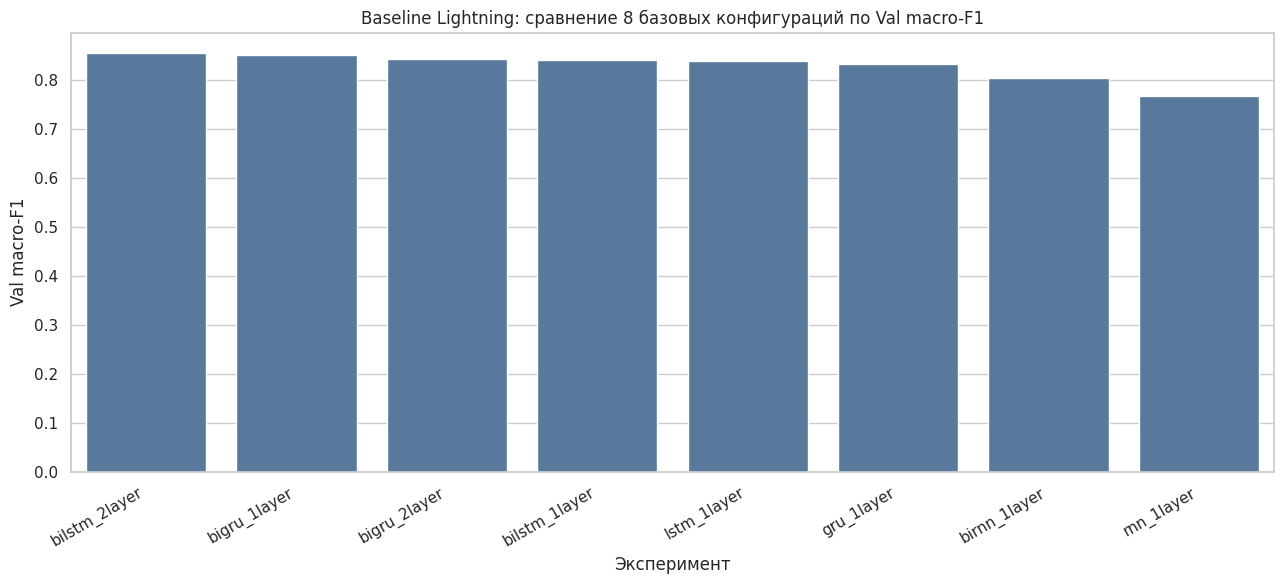

In [13]:
plot_suite_bar(baseline_result["df"], "Baseline Lightning: сравнение 8 базовых конфигураций по Val macro-F1")


## Серия A: входной пайплайн

В этой серии фиксируется сильный baseline `bigru_2layer`, а варьируются только параметры входа:

- размер словаря;
- максимальная длина последовательности.

Это позволяет понять, насколько модель чувствительна именно к ёмкости входного представления.


In [14]:
series_a_configs = []
for vocab_cap, max_seq_len in product([1000, 2000, 3000, FULL_TRAIN_VOCAB_SIZE], [32, 48, 64, 96]):
    series_a_configs.append(
        merge_with_common_config(
            experiment_name=f"bigru2_vocab{vocab_cap}_seq{max_seq_len}",
            suite_name="series_a_input",
            suite_label="Серия A: вход",
            cell_type="GRU",
            bidirectional=True,
            num_layers=2,
            max_vocab_size=int(vocab_cap),
            max_seq_len=int(max_seq_len),
        )
    )

series_a_result = run_experiment_suite("series_a_input", "Серия A: вход", series_a_configs)
display(Markdown("### Результаты серии A"))
display(summarize_suite_df(series_a_result["df"]))
display(Markdown(suite_markdown(series_a_result["df"], "A")))


Seed set to 42


Using 16bit Automatic Mixed Precision (AMP)



===== Запуск блока Серия A: вход =====
Количество запусков: 16
[Серия A: вход] 1/16 -> bigru2_vocab1000_seq32


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


...

[Серия A: вход] bigru2_vocab2202_seq96: val macro-F1=0.8537, test macro-F1=0.8530, время=12.18 сек


/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


### Результаты серии A

,Блок,Эксперимент,Ячейка,Двунаправленная,Слоёв,Embedding,Hidden,Vocab cap,Факт. словарь,Max seq len,Dropout,Recurrent dropout,Embedding dropout,LayerNorm,Оптимизатор,Scheduler,Weight decay,Label smoothing,Лучшая эпоха,"Время обучения, сек",Val accuracy,Val macro-F1,Test accuracy,Test macro-F1
0,Серия A: вход,bigru2_vocab1000_seq96,GRU,Да,2,128,128,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,19,13.45039,0.86193,0.85964,0.86034,0.86120
1,Серия A: вход,bigru2_vocab2202_seq64,GRU,Да,2,128,128,2202,2202,64,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,14,12.12269,0.85893,0.85595,0.85677,0.85731
2,Серия A: вход,bigru2_vocab1000_seq48,GRU,Да,2,128,128,1000,1000,48,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,18,13.07071,0.85843,0.85585,0.86489,0.86564
3,Серия A: вход,bigru2_vocab2000_seq96,GRU,Да,2,128,128,2000,2000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,18,13.41521,0.85643,0.85464,0.85612,0.85645
4,Серия A: вход,bigru2_vocab2202_seq96,GRU,Да,2,128,128,2202,2202,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,14,12.17788,0.85743,0.85370,0.85255,0.85298
5,Серия A: вход,bigru2_vocab1000_seq64,GRU,Да,2,128,128,1000,1000,64,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,11,10.13689,0.85393,0.85249,0.86294,0.86364
6,Серия A: вход,bigru2_vocab1000_seq32,GRU,Да,2,128,128,1000,1000,32,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,13,10.31746,0.85343,0.85076,0.86099,0.86159
7,Серия A: вход,bigru2_vocab2000_seq64,GRU,Да,2,128,128,2000,2000,64,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,10,9.34872,0.85193,0.85036,0.85385,0.85403
8,Серия A: вход,bigru2_vocab2000_seq32,GRU,Да,2,128,128,2000,2000,32,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,7,6.60226,0.85093,0.84665,0.84930,0.85007
9,Серия A: вход,bigru2_vocab3000_seq64,GRU,Да,2,128,128,3000,2204,64,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,13,11.28737,0.84542,0.84502,0.85710,0.85746



### Краткий вывод по блоку A

Лучшим запуском внутри этого блока стал **`bigru2_vocab1000_seq96`**.

- `val macro-F1`: **0.8596**
- `val accuracy`: **0.8619**
- `test macro-F1`: **0.8612**
- `test accuracy`: **0.8603**
- время обучения: **13.45 сек**
- лучшая эпоха: **19**


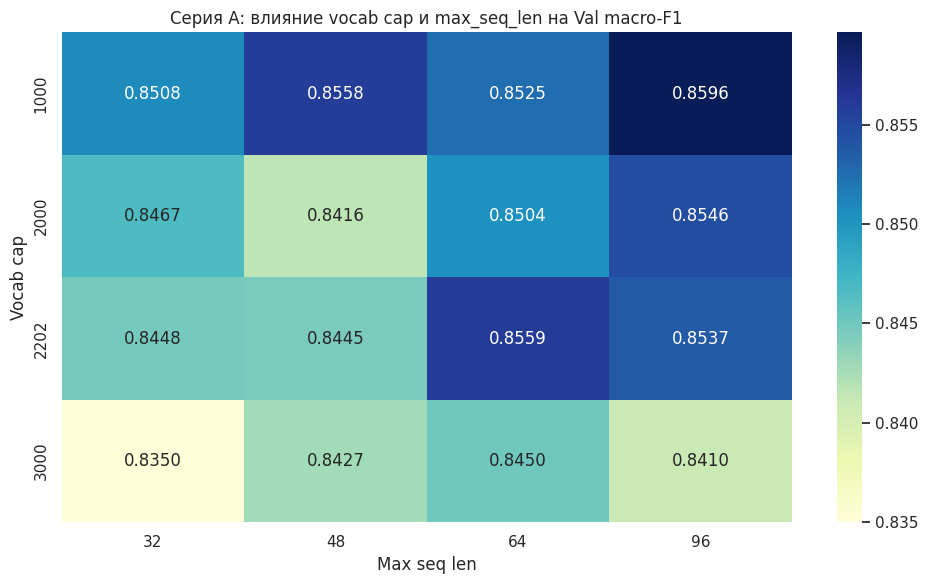

In [15]:
heatmap_df = series_a_result["df"].pivot(index="max_vocab_size_requested", columns="max_seq_len", values="val_f1_macro")
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Серия A: влияние vocab cap и max_seq_len на Val macro-F1")
plt.xlabel("Max seq len")
plt.ylabel("Vocab cap")
plt.tight_layout()
plt.show()


## Серия B: архитектура

В этом блоке фиксируется лучший входной конфиг из серии A. Дальше меняются:

- тип двунаправленного backbone (`BiGRU` или `BiLSTM`);
- число слоёв;
- размер embedding и hidden state.

Так мы проверяем, где именно находится лучший баланс между ёмкостью модели и устойчивостью обучения.


In [16]:
best_input_config = dict(series_a_result["best"]["config"])
series_b_configs = []
for cell_type, num_layers, dims in product(["GRU", "LSTM"], [1, 2, 3], [(128, 128), (256, 256)]):
    embedding_dim, hidden_size = dims
    model_name = "bigru" if cell_type == "GRU" else "bilstm"
    series_b_configs.append(
        merge_with_common_config(
            experiment_name=f"{model_name}_layers{num_layers}_emb{embedding_dim}_hid{hidden_size}",
            suite_name="series_b_architecture",
            suite_label="Серия B: архитектура",
            max_vocab_size=best_input_config["max_vocab_size"],
            max_seq_len=best_input_config["max_seq_len"],
            cell_type=cell_type,
            bidirectional=True,
            num_layers=num_layers,
            embedding_dim=embedding_dim,
            hidden_size=hidden_size,
        )
    )

series_b_result = run_experiment_suite("series_b_architecture", "Серия B: архитектура", series_b_configs)
display(Markdown("### Результаты серии B"))
display(summarize_suite_df(series_b_result["df"]))
display(Markdown(suite_markdown(series_b_result["df"], "B")))


Seed set to 42


Using 16bit Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

[Серия B: архитектура] bilstm_layers3_emb256_hid256: val macro-F1=0.8490, test macro-F1=0.8573, время=17.69 сек


/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


### Результаты серии B

,Блок,Эксперимент,Ячейка,Двунаправленная,Слоёв,Embedding,Hidden,Vocab cap,Факт. словарь,Max seq len,Dropout,Recurrent dropout,Embedding dropout,LayerNorm,Оптимизатор,Scheduler,Weight decay,Label smoothing,Лучшая эпоха,"Время обучения, сек",Val accuracy,Val macro-F1,Test accuracy,Test macro-F1
0,Серия B: архитектура,bigru_layers3_emb256_hid256,GRU,Да,3,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,11,12.49092,0.87594,0.87559,0.87853,0.87826
1,Серия B: архитектура,bigru_layers1_emb256_hid256,GRU,Да,1,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,11,8.25909,0.87344,0.87519,0.87171,0.87238
2,Серия B: архитектура,bilstm_layers2_emb256_hid256,LSTM,Да,2,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,13,11.94080,0.87644,0.87328,0.87431,0.87430
3,Серия B: архитектура,bigru_layers2_emb256_hid256,GRU,Да,2,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,6,7.02104,0.87044,0.86820,0.87334,0.87373
4,Серия B: архитектура,bilstm_layers1_emb256_hid256,LSTM,Да,1,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,15,10.33957,0.86793,0.86555,0.86911,0.86885
5,Серия B: архитектура,bigru_layers2_emb128_hid128,GRU,Да,2,128,128,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,19,13.58998,0.86193,0.85964,0.86034,0.86120
6,Серия B: архитектура,bigru_layers3_emb128_hid128,GRU,Да,3,128,128,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,14,14.43508,0.86043,0.85928,0.85807,0.85865
7,Серия B: архитектура,bilstm_layers3_emb256_hid256,LSTM,Да,3,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,16,17.69335,0.85143,0.84896,0.85775,0.85735
8,Серия B: архитектура,bilstm_layers1_emb128_hid128,LSTM,Да,1,128,128,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,13,9.07732,0.84742,0.84447,0.85612,0.85642
9,Серия B: архитектура,bigru_layers1_emb128_hid128,GRU,Да,1,128,128,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,19,10.40883,0.84392,0.84143,0.85547,0.85545



### Краткий вывод по блоку B

Лучшим запуском внутри этого блока стал **`bigru_layers3_emb256_hid256`**.

- `val macro-F1`: **0.8756**
- `val accuracy`: **0.8759**
- `test macro-F1`: **0.8783**
- `test accuracy`: **0.8785**
- время обучения: **12.49 сек**
- лучшая эпоха: **11**


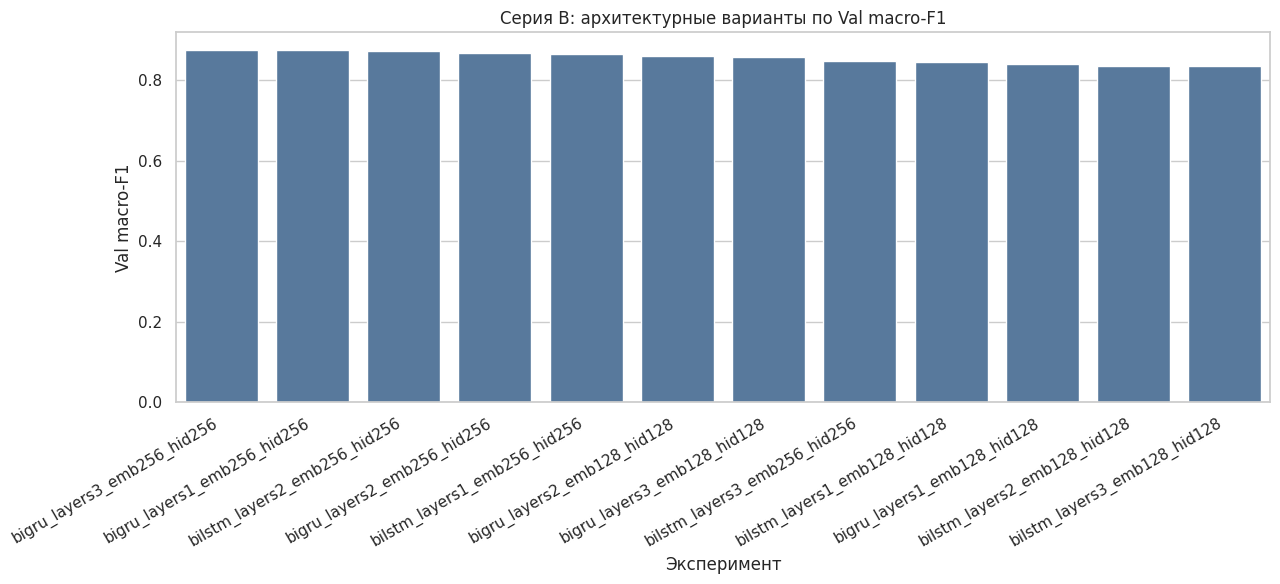

In [17]:
plot_suite_bar(series_b_result["df"], "Серия B: архитектурные варианты по Val macro-F1")


## Серия C: регуляризация и нормализация

На этом шаге используется лучшая архитектура из серии B. Теперь интересует не размер модели, а качество её регуляризации:

- `dropout`;
- `recurrent_dropout`;
- `embedding_dropout`;
- `LayerNorm`.

Именно здесь ожидается снижение текущего переобучения, которое было видно в базовом RNN-блоке.


In [18]:
best_arch_config = dict(series_b_result["best"]["config"])
series_c_configs = []
for dropout, recurrent_dropout, embedding_dropout, use_layer_norm in product([0.3, 0.5], [0.0, 0.2], [0.0, 0.2], [False, True]):
    series_c_configs.append(
        merge_with_common_config(
            experiment_name=f"reg_do{dropout}_rdo{recurrent_dropout}_edo{embedding_dropout}_ln{int(use_layer_norm)}",
            suite_name="series_c_regularization",
            suite_label="Серия C: регуляризация",
            max_vocab_size=best_arch_config["max_vocab_size"],
            max_seq_len=best_arch_config["max_seq_len"],
            cell_type=best_arch_config["cell_type"],
            bidirectional=best_arch_config["bidirectional"],
            num_layers=best_arch_config["num_layers"],
            embedding_dim=best_arch_config["embedding_dim"],
            hidden_size=best_arch_config["hidden_size"],
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            embedding_dropout=embedding_dropout,
            use_layer_norm=use_layer_norm,
        )
    )

series_c_result = run_experiment_suite("series_c_regularization", "Серия C: регуляризация", series_c_configs)
display(Markdown("### Результаты серии C"))
display(summarize_suite_df(series_c_result["df"]))
display(Markdown(suite_markdown(series_c_result["df"], "C")))


Seed set to 42


Using 16bit Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

[Серия C: регуляризация] reg_do0.5_rdo0.2_edo0.2_ln1: val macro-F1=0.8653, test macro-F1=0.8769, время=13.63 сек


/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


### Результаты серии C

,Блок,Эксперимент,Ячейка,Двунаправленная,Слоёв,Embedding,Hidden,Vocab cap,Факт. словарь,Max seq len,Dropout,Recurrent dropout,Embedding dropout,LayerNorm,Оптимизатор,Scheduler,Weight decay,Label smoothing,Лучшая эпоха,"Время обучения, сек",Val accuracy,Val macro-F1,Test accuracy,Test macro-F1
0,Серия C: регуляризация,reg_do0.5_rdo0.0_edo0.0_ln1,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,none,0.0001,0.0,16,17.06940,0.88044,0.87857,0.88698,0.88725
1,Серия C: регуляризация,reg_do0.3_rdo0.0_edo0.0_ln0,GRU,Да,3,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,none,0.0001,0.0,11,12.77298,0.87594,0.87559,0.87853,0.87826
2,Серия C: регуляризация,reg_do0.3_rdo0.0_edo0.2_ln0,GRU,Да,3,256,256,1000,1000,96,0.3,0.0,0.2,Нет,AdamW,none,0.0001,0.0,10,11.91408,0.87594,0.87530,0.88048,0.88041
3,Серия C: регуляризация,reg_do0.3_rdo0.0_edo0.2_ln1,GRU,Да,3,256,256,1000,1000,96,0.3,0.0,0.2,Да,AdamW,none,0.0001,0.0,16,17.30741,0.87344,0.87481,0.88373,0.88386
4,Серия C: регуляризация,reg_do0.3_rdo0.2_edo0.0_ln0,GRU,Да,3,256,256,1000,1000,96,0.3,0.2,0.0,Нет,AdamW,none,0.0001,0.0,8,10.28707,0.87594,0.87365,0.87269,0.87247
5,Серия C: регуляризация,reg_do0.5_rdo0.2_edo0.0_ln0,GRU,Да,3,256,256,1000,1000,96,0.5,0.2,0.0,Нет,AdamW,none,0.0001,0.0,12,13.67532,0.87194,0.87236,0.86814,0.86837
6,Серия C: регуляризация,reg_do0.3_rdo0.2_edo0.2_ln0,GRU,Да,3,256,256,1000,1000,96,0.3,0.2,0.2,Нет,AdamW,none,0.0001,0.0,7,9.30885,0.87344,0.87210,0.86489,0.86477
7,Серия C: регуляризация,reg_do0.5_rdo0.0_edo0.2_ln0,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.2,Нет,AdamW,none,0.0001,0.0,10,11.68723,0.87094,0.86979,0.87691,0.87671
8,Серия C: регуляризация,reg_do0.3_rdo0.0_edo0.0_ln1,GRU,Да,3,256,256,1000,1000,96,0.3,0.0,0.0,Да,AdamW,none,0.0001,0.0,15,16.05525,0.86943,0.86828,0.88178,0.88169
9,Серия C: регуляризация,reg_do0.5_rdo0.2_edo0.2_ln0,GRU,Да,3,256,256,1000,1000,96,0.5,0.2,0.2,Нет,AdamW,none,0.0001,0.0,14,15.49172,0.86793,0.86787,0.87204,0.87206



### Краткий вывод по блоку C

Лучшим запуском внутри этого блока стал **`reg_do0.5_rdo0.0_edo0.0_ln1`**.

- `val macro-F1`: **0.8786**
- `val accuracy`: **0.8804**
- `test macro-F1`: **0.8872**
- `test accuracy`: **0.8870**
- время обучения: **17.07 сек**
- лучшая эпоха: **16**


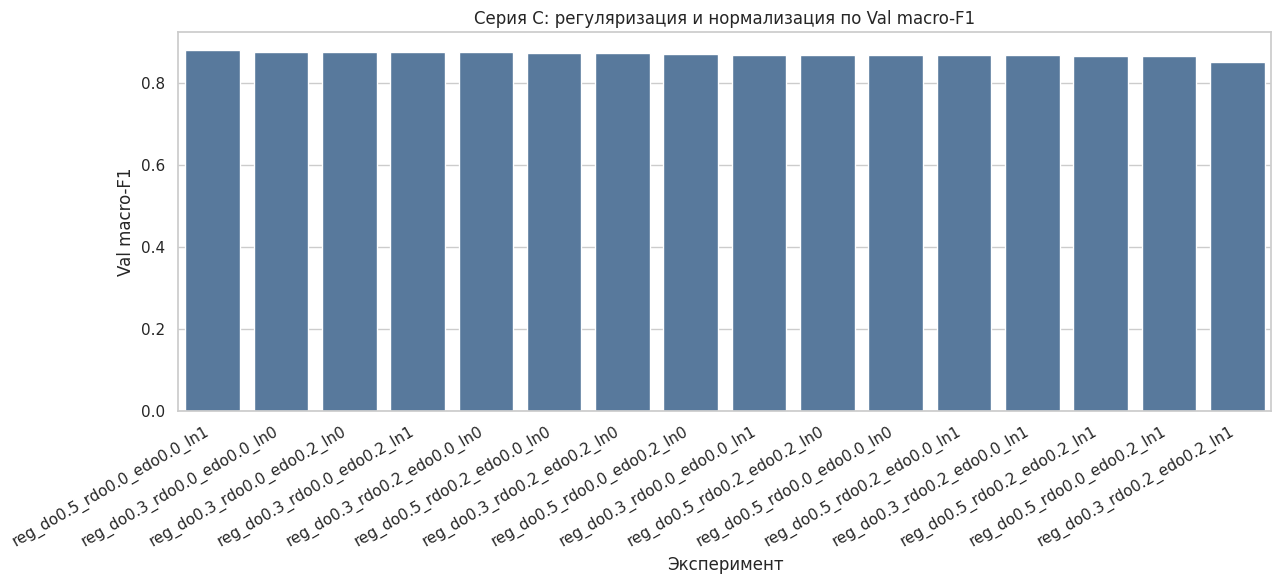

In [19]:
plot_suite_bar(series_c_result["df"], "Серия C: регуляризация и нормализация по Val macro-F1")


## Серия D: оптимизация

Теперь фиксируется лучший конфиг из серии C. Последний блок одиночных абляций посвящён оптимизации:

- выбор optimizer;
- наличие scheduler;
- weight decay;
- label smoothing.

Это позволяет проверить, можно ли получить дополнительный прирост качества не меняя архитектуру, а меняя только режим обучения.


In [20]:
best_reg_config = dict(series_c_result["best"]["config"])
series_d_configs = []
for optimizer_name, scheduler_name, weight_decay, label_smoothing in product(["AdamW", "RMSprop", "NAdam"], ["none", "reduce_on_plateau"], [1e-4, 5e-4], [0.0, 0.05]):
    series_d_configs.append(
        merge_with_common_config(
            experiment_name=f"opt_{optimizer_name.lower()}_{scheduler_name}_wd{weight_decay}_ls{label_smoothing}",
            suite_name="series_d_optimization",
            suite_label="Серия D: оптимизация",
            max_vocab_size=best_reg_config["max_vocab_size"],
            max_seq_len=best_reg_config["max_seq_len"],
            cell_type=best_reg_config["cell_type"],
            bidirectional=best_reg_config["bidirectional"],
            num_layers=best_reg_config["num_layers"],
            embedding_dim=best_reg_config["embedding_dim"],
            hidden_size=best_reg_config["hidden_size"],
            dropout=best_reg_config["dropout"],
            recurrent_dropout=best_reg_config["recurrent_dropout"],
            embedding_dropout=best_reg_config["embedding_dropout"],
            use_layer_norm=best_reg_config["use_layer_norm"],
            optimizer_name=optimizer_name,
            scheduler_name=scheduler_name,
            weight_decay=weight_decay,
            label_smoothing=label_smoothing,
        )
    )

series_d_result = run_experiment_suite("series_d_optimization", "Серия D: оптимизация", series_d_configs)
display(Markdown("### Результаты серии D"))
display(summarize_suite_df(series_d_result["df"]))
display(Markdown(suite_markdown(series_d_result["df"], "D")))


Seed set to 42


Using 16bit Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

[Серия D: оптимизация] opt_nadam_reduce_on_plateau_wd0.0005_ls0.05: val macro-F1=0.8592, test macro-F1=0.8719, время=17.35 сек


/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


### Результаты серии D

,Блок,Эксперимент,Ячейка,Двунаправленная,Слоёв,Embedding,Hidden,Vocab cap,Факт. словарь,Max seq len,Dropout,Recurrent dropout,Embedding dropout,LayerNorm,Оптимизатор,Scheduler,Weight decay,Label smoothing,Лучшая эпоха,"Время обучения, сек",Val accuracy,Val macro-F1,Test accuracy,Test macro-F1
0,Серия D: оптимизация,opt_adamw_reduce_on_plateau_wd0.0005_ls0.05,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,reduce_on_plateau,0.0005,0.05,13,14.52798,0.89095,0.89074,0.89380,0.89398
1,Серия D: оптимизация,opt_adamw_reduce_on_plateau_wd0.0001_ls0.05,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,reduce_on_plateau,0.0001,0.05,13,14.54271,0.89095,0.89074,0.89380,0.89397
2,Серия D: оптимизация,opt_adamw_none_wd0.0001_ls0.05,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,none,0.0001,0.05,9,11.16674,0.88294,0.88188,0.88925,0.88898
3,Серия D: оптимизация,opt_adamw_none_wd0.0005_ls0.05,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,none,0.0005,0.05,9,11.15625,0.88294,0.88188,0.88925,0.88896
4,Серия D: оптимизация,opt_adamw_none_wd0.0001_ls0.0,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,none,0.0001,0.00,16,16.86491,0.88044,0.87857,0.88698,0.88725
5,Серия D: оптимизация,opt_adamw_reduce_on_plateau_wd0.0001_ls0.0,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,reduce_on_plateau,0.0001,0.00,15,16.01298,0.87594,0.87695,0.88698,0.88707
6,Серия D: оптимизация,opt_nadam_reduce_on_plateau_wd0.0001_ls0.05,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,NAdam,reduce_on_plateau,0.0001,0.05,9,11.36032,0.87694,0.87648,0.88340,0.88340
7,Серия D: оптимизация,opt_rmsprop_reduce_on_plateau_wd0.0001_ls0.05,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,RMSprop,reduce_on_plateau,0.0001,0.05,18,16.70179,0.87494,0.87400,0.88860,0.88855
8,Серия D: оптимизация,opt_adamw_none_wd0.0005_ls0.0,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,none,0.0005,0.00,14,15.30019,0.87394,0.87393,0.88146,0.88204
9,Серия D: оптимизация,opt_adamw_reduce_on_plateau_wd0.0005_ls0.0,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,reduce_on_plateau,0.0005,0.00,14,15.11126,0.87394,0.87393,0.88146,0.88204



### Краткий вывод по блоку D

Лучшим запуском внутри этого блока стал **`opt_adamw_reduce_on_plateau_wd0.0005_ls0.05`**.

- `val macro-F1`: **0.8907**
- `val accuracy`: **0.8910**
- `test macro-F1`: **0.8940**
- `test accuracy`: **0.8938**
- время обучения: **14.53 сек**
- лучшая эпоха: **13**


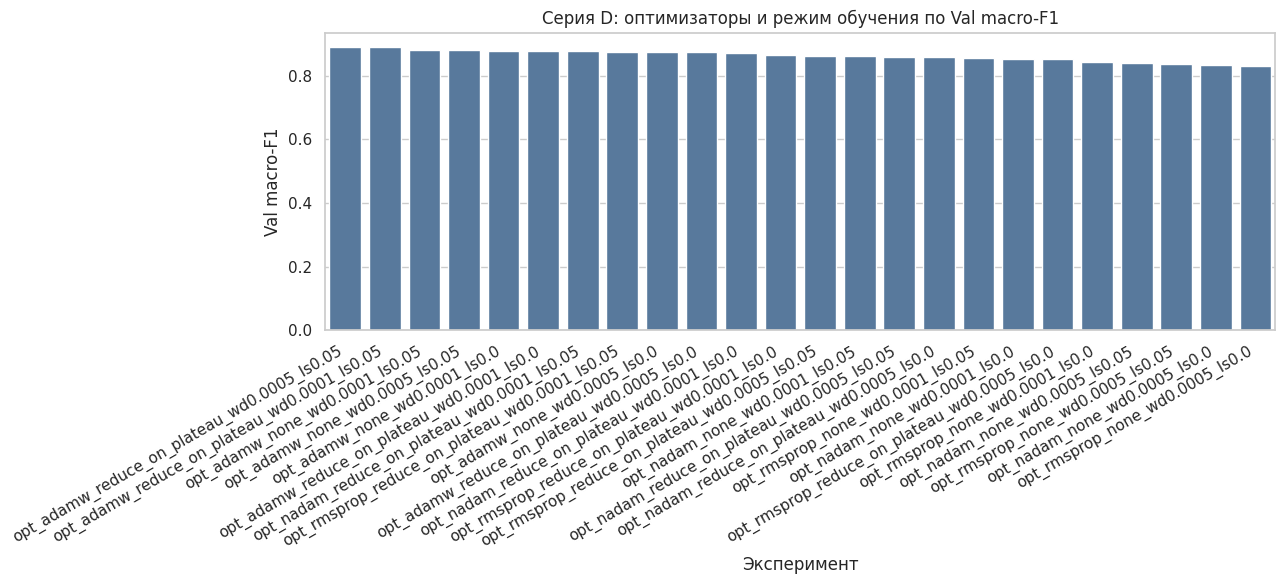

In [21]:
plot_suite_bar(series_d_result["df"], "Серия D: оптимизаторы и режим обучения по Val macro-F1")


## Серия E: связки лучших решений

После одиночных абляций ниже собираются финальные комбинации из top-2 решений блоков A-D. Полный декартов продукт дал бы 16 вариантов, но здесь используются 8 лучших комбинаций по сумме рангов исходных решений. Это позволяет проверить уже не отдельные факторы, а их совместную работу.


In [22]:
INPUT_KEYS = ["max_vocab_size", "max_seq_len"]
ARCH_KEYS = ["cell_type", "bidirectional", "num_layers", "embedding_dim", "hidden_size"]
REG_KEYS = ["dropout", "recurrent_dropout", "embedding_dropout", "use_layer_norm"]
OPT_KEYS = ["optimizer_name", "scheduler_name", "weight_decay", "label_smoothing", "lr"]


def extract_key_subset(config: dict, keys: list[str]) -> dict:
    return {key: config[key] for key in keys}


top_inputs = get_top_configs(series_a_result, top_n=2)
top_architectures = get_top_configs(series_b_result, top_n=2)
top_regularizations = get_top_configs(series_c_result, top_n=2)
top_optimizations = get_top_configs(series_d_result, top_n=2)

combo_candidates = []
for input_item, arch_item, reg_item, opt_item in product(top_inputs, top_architectures, top_regularizations, top_optimizations):
    combo_candidates.append(
        {
            "score": input_item["rank"] + arch_item["rank"] + reg_item["rank"] + opt_item["rank"],
            "input_rank": input_item["rank"],
            "arch_rank": arch_item["rank"],
            "reg_rank": reg_item["rank"],
            "opt_rank": opt_item["rank"],
            "config": {
                **extract_key_subset(input_item["config"], INPUT_KEYS),
                **extract_key_subset(arch_item["config"], ARCH_KEYS),
                **extract_key_subset(reg_item["config"], REG_KEYS),
                **extract_key_subset(opt_item["config"], OPT_KEYS),
            },
        }
    )

combo_candidates = sorted(
    combo_candidates,
    key=lambda item: (item["score"], item["input_rank"], item["arch_rank"], item["reg_rank"], item["opt_rank"]),
)[:8]

series_e_configs = []
for index, candidate in enumerate(combo_candidates, start=1):
    merged = candidate["config"]
    series_e_configs.append(
        merge_with_common_config(
            experiment_name=f"combo_{index:02d}_a{candidate['input_rank']}_b{candidate['arch_rank']}_c{candidate['reg_rank']}_d{candidate['opt_rank']}",
            suite_name="series_e_combinations",
            suite_label="Серия E: связки",
            **merged,
        )
    )

series_e_result = run_experiment_suite("series_e_combinations", "Серия E: связки", series_e_configs)
display(Markdown("### Результаты серии E"))
display(summarize_suite_df(series_e_result["df"]))
display(Markdown(suite_markdown(series_e_result["df"], "E")))


Seed set to 42


Using 16bit Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

[Серия E: связки] combo_08_a1_b2_c2_d1: val macro-F1=0.8776, test macro-F1=0.8797, время=7.96 сек


/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


### Результаты серии E

,Блок,Эксперимент,Ячейка,Двунаправленная,Слоёв,Embedding,Hidden,Vocab cap,Факт. словарь,Max seq len,Dropout,Recurrent dropout,Embedding dropout,LayerNorm,Оптимизатор,Scheduler,Weight decay,Label smoothing,Лучшая эпоха,"Время обучения, сек",Val accuracy,Val macro-F1,Test accuracy,Test macro-F1
0,Серия E: связки,combo_01_a1_b1_c1_d1,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,reduce_on_plateau,0.0005,0.05,13,14.53592,0.89095,0.89074,0.89380,0.89398
1,Серия E: связки,combo_02_a1_b1_c1_d2,GRU,Да,3,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,reduce_on_plateau,0.0001,0.05,13,14.60813,0.89095,0.89074,0.89380,0.89397
2,Серия E: связки,combo_03_a1_b1_c2_d1,GRU,Да,3,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,reduce_on_plateau,0.0005,0.05,12,13.62000,0.88644,0.88708,0.89250,0.89251
3,Серия E: связки,combo_06_a1_b1_c2_d2,GRU,Да,3,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,reduce_on_plateau,0.0001,0.05,12,13.40555,0.88644,0.88708,0.89250,0.89251
4,Серия E: связки,combo_05_a2_b1_c1_d1,GRU,Да,3,256,256,2202,2202,64,0.5,0.0,0.0,Да,AdamW,reduce_on_plateau,0.0005,0.05,10,12.24355,0.88644,0.88680,0.88957,0.88940
5,Серия E: связки,combo_04_a1_b2_c1_d1,GRU,Да,1,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,reduce_on_plateau,0.0005,0.05,14,9.74488,0.87844,0.87821,0.87723,0.87746
6,Серия E: связки,combo_07_a1_b2_c1_d2,GRU,Да,1,256,256,1000,1000,96,0.5,0.0,0.0,Да,AdamW,reduce_on_plateau,0.0001,0.05,14,9.87354,0.87844,0.87821,0.87723,0.87746
7,Серия E: связки,combo_08_a1_b2_c2_d1,GRU,Да,1,256,256,1000,1000,96,0.3,0.0,0.0,Нет,AdamW,reduce_on_plateau,0.0005,0.05,11,7.96268,0.87494,0.87765,0.87951,0.87968



### Краткий вывод по блоку E

Лучшим запуском внутри этого блока стал **`combo_01_a1_b1_c1_d1`**.

- `val macro-F1`: **0.8907**
- `val accuracy`: **0.8910**
- `test macro-F1`: **0.8940**
- `test accuracy`: **0.8938**
- время обучения: **14.54 сек**
- лучшая эпоха: **13**


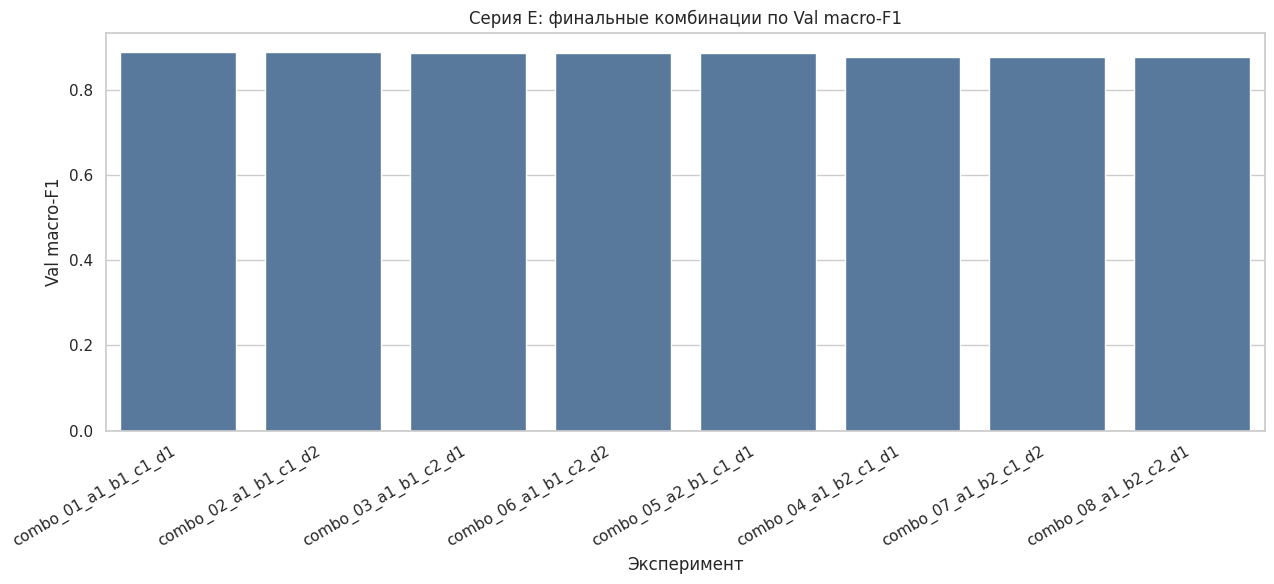

In [23]:
plot_suite_bar(series_e_result["df"], "Серия E: финальные комбинации по Val macro-F1")


## Общее сравнение: classic baseline, untuned RNN и tuned RNN

Теперь можно собрать три ключевые точки сравнения:

- лучшая классическая модель из ноутбука `02`;
- лучшая baseline RNN-модель без широкой настройки;
- лучшая tuned RNN-модель после серий A-E.

Именно этот срез показывает, удалось ли нейросетевому подходу приблизиться к сильному TF-IDF baseline или превзойти его.


In [24]:
all_suite_results = [baseline_result, series_a_result, series_b_result, series_c_result, series_d_result, series_e_result]
all_experiment_log_df = pd.concat([suite["df"] for suite in all_suite_results], ignore_index=True)

best_baseline_rnn = baseline_result["best"]
best_tuned_rnn = series_e_result["best"]
best_tuned_history_df = best_tuned_rnn["history_df"].copy()
classic_best_row = load_best_classic_result()

comparison_rows = [
    {
        "model_family": "RNN baseline",
        "model_name": best_baseline_rnn["experiment_name"],
        "val_f1_macro": best_baseline_rnn["val_metrics"]["f1_macro"],
        "test_f1_macro": best_baseline_rnn["test_metrics"]["f1_macro"],
        "test_accuracy": best_baseline_rnn["test_metrics"]["accuracy"],
    },
    {
        "model_family": "RNN tuned",
        "model_name": best_tuned_rnn["experiment_name"],
        "val_f1_macro": best_tuned_rnn["val_metrics"]["f1_macro"],
        "test_f1_macro": best_tuned_rnn["test_metrics"]["f1_macro"],
        "test_accuracy": best_tuned_rnn["test_metrics"]["accuracy"],
    },
]
if classic_best_row is not None:
    comparison_rows.insert(
        0,
        {
            "model_family": "Classic baseline from 02",
            "model_name": classic_best_row.get("candidate", classic_best_row.get("candidate_name", "unknown")),
            "val_f1_macro": classic_best_row.get("val_f1_macro", np.nan),
            "test_f1_macro": classic_best_row.get("test_f1_macro", classic_best_row.get("f1_macro", np.nan)),
            "test_accuracy": classic_best_row.get("test_accuracy", classic_best_row.get("accuracy", np.nan)),
        },
    )
comparison_df = pd.DataFrame(comparison_rows)

display(Markdown("### Сравнение лучших итоговых моделей"))
display(comparison_df)

display(
    Markdown(
        f"""
### Итог выбора лучшей tuned RNN-модели

Лучшей настроенной конфигурацией после серии A-E стала модель **`{best_tuned_rnn['experiment_name']}`**.

- `val macro-F1`: **{best_tuned_rnn['val_metrics']['f1_macro']:.4f}**
- `val accuracy`: **{best_tuned_rnn['val_metrics']['accuracy']:.4f}**
- `test macro-F1`: **{best_tuned_rnn['test_metrics']['f1_macro']:.4f}**
- `test accuracy`: **{best_tuned_rnn['test_metrics']['accuracy']:.4f}**
- лучшая эпоха: **{best_tuned_rnn['best_epoch']}**
- время обучения: **{best_tuned_rnn['fit_sec']:.2f} сек**

Напоминание: лучшая конфигурация всё равно выбирается по `val`, а `test` здесь приведён как справочная финальная оценка.
"""
    )
)


### Сравнение лучших итоговых моделей

,model_family,model_name,val_f1_macro,test_f1_macro,test_accuracy
0,Classic baseline from 02,lr_tfidf_40k_bigrams_c2,0.853450,0.867630,0.867490
1,RNN baseline,bilstm_2layer,0.853725,0.854986,0.853849
2,RNN tuned,combo_01_a1_b1_c1_d1,0.890744,0.893976,0.893797



### Итог выбора лучшей tuned RNN-модели

Лучшей настроенной конфигурацией после серии A-E стала модель **`combo_01_a1_b1_c1_d1`**.

- `val macro-F1`: **0.8907**
- `val accuracy`: **0.8909**
- `test macro-F1`: **0.8940**
- `test accuracy`: **0.8938**
- лучшая эпоха: **13**
- время обучения: **14.54 сек**

Напоминание: лучшая конфигурация всё равно выбирается по `val`, а `test` здесь приведён как справочная финальная оценка.


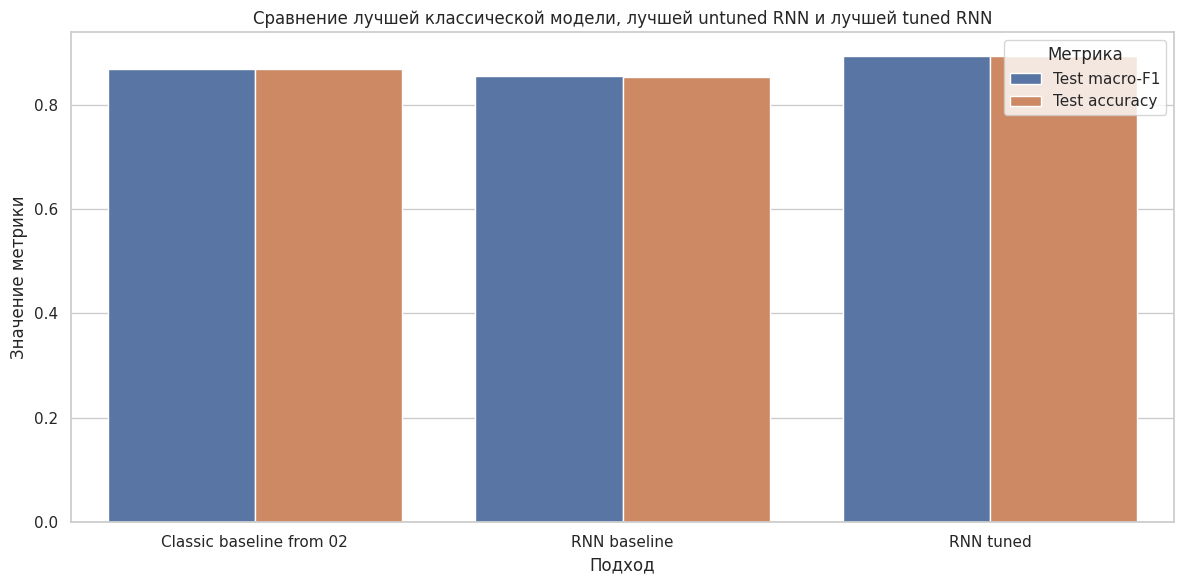

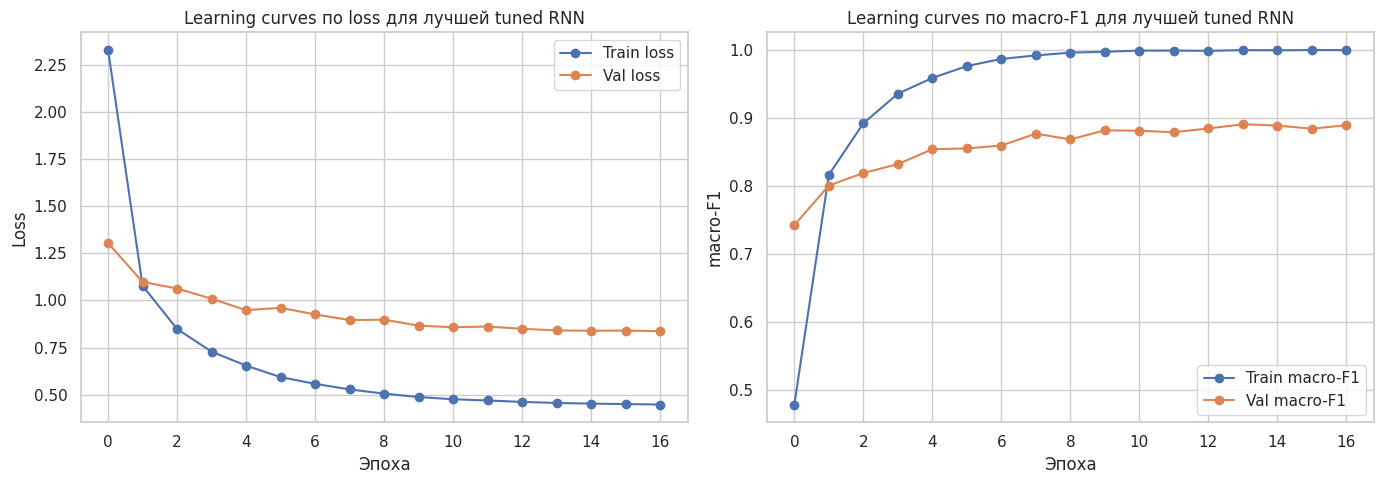

In [25]:
comparison_plot_df = comparison_df.melt(
    id_vars=["model_family", "model_name"],
    value_vars=["test_f1_macro", "test_accuracy"],
    var_name="metric",
    value_name="value",
)
comparison_plot_df["metric"] = comparison_plot_df["metric"].map(
    {
        "test_f1_macro": "Test macro-F1",
        "test_accuracy": "Test accuracy",
    }
)

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_plot_df, x="model_family", y="value", hue="metric")
plt.title("Сравнение лучшей классической модели, лучшей untuned RNN и лучшей tuned RNN")
plt.xlabel("Подход")
plt.ylabel("Значение метрики")
plt.legend(title="Метрика")
plt.tight_layout()
plt.show()

if not best_tuned_history_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(best_tuned_history_df["epoch"], best_tuned_history_df["train_loss"], marker="o", label="Train loss")
    axes[0].plot(best_tuned_history_df["epoch"], best_tuned_history_df["val_loss"], marker="o", label="Val loss")
    axes[0].set_title("Learning curves по loss для лучшей tuned RNN")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(best_tuned_history_df["epoch"], best_tuned_history_df["train_f1_macro"], marker="o", label="Train macro-F1")
    axes[1].plot(best_tuned_history_df["epoch"], best_tuned_history_df["val_f1_macro"], marker="o", label="Val macro-F1")
    axes[1].set_title("Learning curves по macro-F1 для лучшей tuned RNN")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("macro-F1")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## Анализ ошибок лучшей tuned RNN-модели

После выбора лучшей конфигурации нужно понять, на каких классах она всё ещё ошибается. Для прикладной системы маршрутизации это не менее важно, чем общий `macro-F1`.


In [26]:
best_tuned_test_output = best_tuned_rnn["test_prediction_output"]
best_tuned_predictions_df = build_predictions_frame(
    texts=best_tuned_test_output["texts"],
    texts_normalized=best_tuned_test_output["texts_normalized"],
    y_true=best_tuned_test_output["labels"],
    y_pred=best_tuned_test_output["preds"],
    label_names=label_names,
)
best_tuned_per_class_df = per_class_metrics_frame(
    best_tuned_test_output["labels"],
    best_tuned_test_output["preds"],
    label_names,
)
weakest_classes_df = best_tuned_per_class_df.sort_values(["f1", "support"], ascending=[True, False]).head(15)
strongest_classes_df = best_tuned_per_class_df.sort_values(["f1", "support"], ascending=[False, False]).head(15)
confusion_pairs_df = most_confused_pairs(best_tuned_predictions_df, top_n=15)
error_examples_df = (
    best_tuned_predictions_df.loc[
        ~best_tuned_predictions_df["is_correct"],
        ["text", "label_name", "prediction_name"],
    ]
    .head(12)
    .reset_index(drop=True)
)

display(Markdown("### Слабые классы лучшей tuned RNN"))
display(weakest_classes_df)

display(Markdown("### Сильные классы лучшей tuned RNN"))
display(strongest_classes_df)

display(Markdown("### Наиболее частые пары ошибок"))
display(confusion_pairs_df)

display(Markdown("### Примеры ошибочных предсказаний"))
display(error_examples_df)


### Слабые классы лучшей tuned RNN

,label,label_name,precision,recall,f1,support
0,5,balance_not_updated_after_bank_transfer,0.704545,0.775,0.738095,40
1,35,failed_transfer,0.687500,0.825,0.750000,40
2,48,pending_transfer,0.805556,0.725,0.763158,40
3,62,topping_up_by_card,0.810811,0.750,0.779221,40
4,22,compromised_card,0.857143,0.750,0.800000,40
5,25,declined_card_payment,0.760870,0.875,0.813953,40
6,16,card_payment_not_recognised,0.804878,0.825,0.814815,40
7,66,transfer_not_received_by_recipient,0.804878,0.825,0.814815,40
8,74,why_verify_identity,0.804878,0.825,0.814815,40
9,12,card_delivery_estimate,0.790698,0.850,0.819277,40


### Сильные классы лучшей tuned RNN

,label,label_name,precision,recall,f1,support
75,2,apple_pay_or_google_pay,1.000000,1.000,1.000000,40
76,44,passcode_forgotten,1.000000,1.000,1.000000,40
73,60,top_up_limits,0.975610,1.000,0.987654,40
74,70,verify_source_of_funds,0.975610,1.000,0.987654,40
71,1,age_limit,0.975000,0.975,0.975000,40
72,4,automatic_top_up,0.975000,0.975,0.975000,40
70,0,activate_my_card,1.000000,0.950,0.974359,40
68,30,edit_personal_details,0.930233,1.000,0.963855,40
69,71,verify_top_up,0.930233,1.000,0.963855,40
67,34,extra_charge_on_statement,0.951220,0.975,0.962963,40


### Наиболее частые пары ошибок

,label_name,prediction_name,count
0,card_payment_not_recognised,compromised_card,5
1,why_verify_identity,verify_my_identity,5
2,card_acceptance,card_not_working,4
3,fiat_currency_support,exchange_via_app,4
4,balance_not_updated_after_bank_transfer,pending_transfer,4
5,pending_transfer,transfer_timing,4
6,top_up_by_bank_transfer_charge,transfer_fee_charged,4
7,unable_to_verify_identity,why_verify_identity,4
8,beneficiary_not_allowed,failed_transfer,3
9,declined_transfer,failed_transfer,3


### Примеры ошибочных предсказаний

,text,label_name,prediction_name
0,How do I locate my card?,card_arrival,order_physical_card
1,When will I get my card?,card_arrival,card_delivery_estimate
2,How long does a card delivery take?,card_arrival,card_delivery_estimate
3,How do I know when my card will arrive?,card_arrival,card_delivery_estimate
4,"I'm starting to think my card is lost because it still hasn't arrived, can you help?",card_arrival,lost_or_stolen_card
5,The app doesn't show the card I received.,card_linking,unable_to_verify_identity
6,Can I link another card to my account?,card_linking,getting_spare_card
7,Is it a good time to exchange?,exchange_rate,exchange_charge
8,What kind of foreign exchange rate will I get when I exchange my money?,exchange_rate,wrong_exchange_rate_for_cash_withdrawal
9,I made a currency exchange and think I was charged more than I should of been.,card_payment_wrong_exchange_rate,extra_charge_on_statement


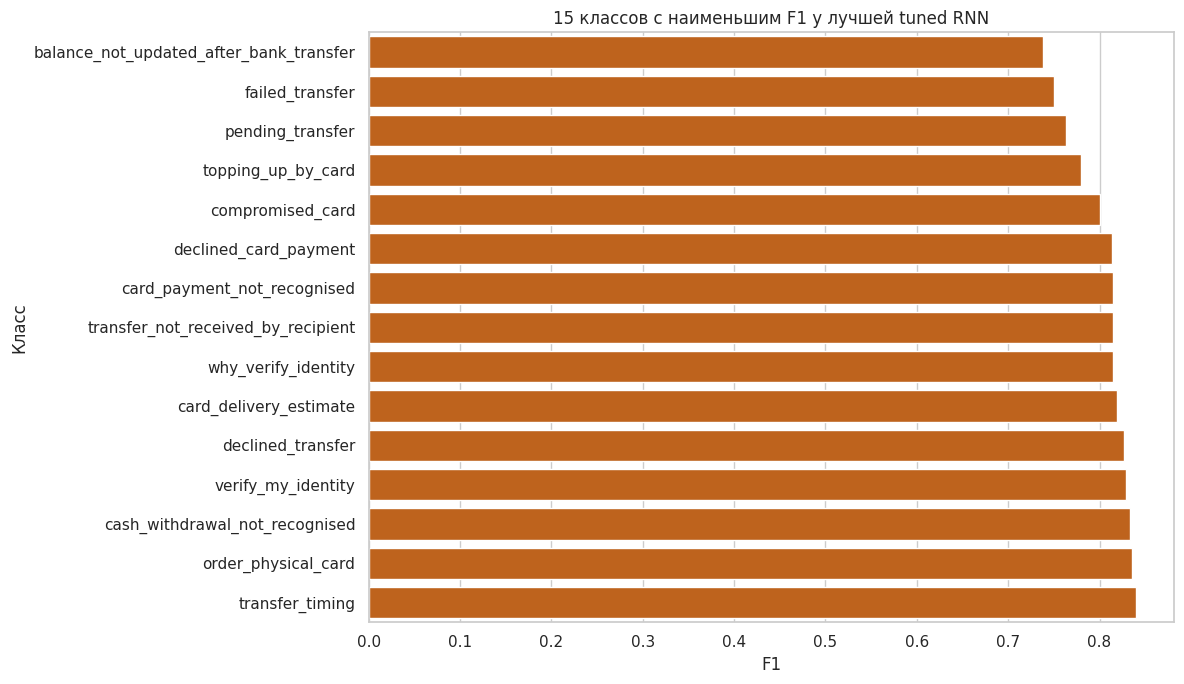

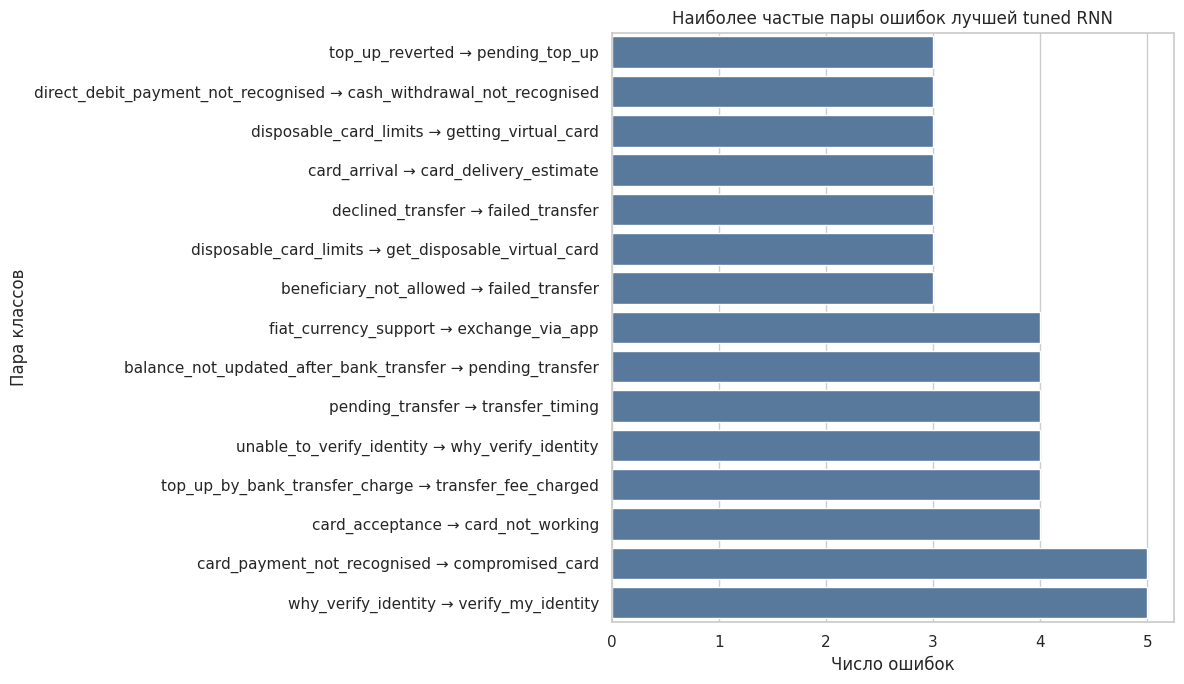

In [27]:
plt.figure(figsize=(12, 7))
plot_df = weakest_classes_df.sort_values("f1", ascending=True)
sns.barplot(data=plot_df, y="label_name", x="f1", color="#D95F02")
plt.title("15 классов с наименьшим F1 у лучшей tuned RNN")
plt.xlabel("F1")
plt.ylabel("Класс")
plt.tight_layout()
plt.show()

if not confusion_pairs_df.empty:
    plot_df = confusion_pairs_df.copy()
    plot_df["pair"] = plot_df["label_name"] + " → " + plot_df["prediction_name"]
    plt.figure(figsize=(12, 7))
    sns.barplot(data=plot_df.sort_values("count", ascending=True), y="pair", x="count", color="#4C78A8")
    plt.title("Наиболее частые пары ошибок лучшей tuned RNN")
    plt.xlabel("Число ошибок")
    plt.ylabel("Пара классов")
    plt.tight_layout()
    plt.show()


## Сохранение артефактов

Ниже сохраняются summary-таблицы, логи экспериментов, best checkpoint, таблицы ошибок и артефакты для дальнейшего использования в отчёте и в следующем шаге проекта.


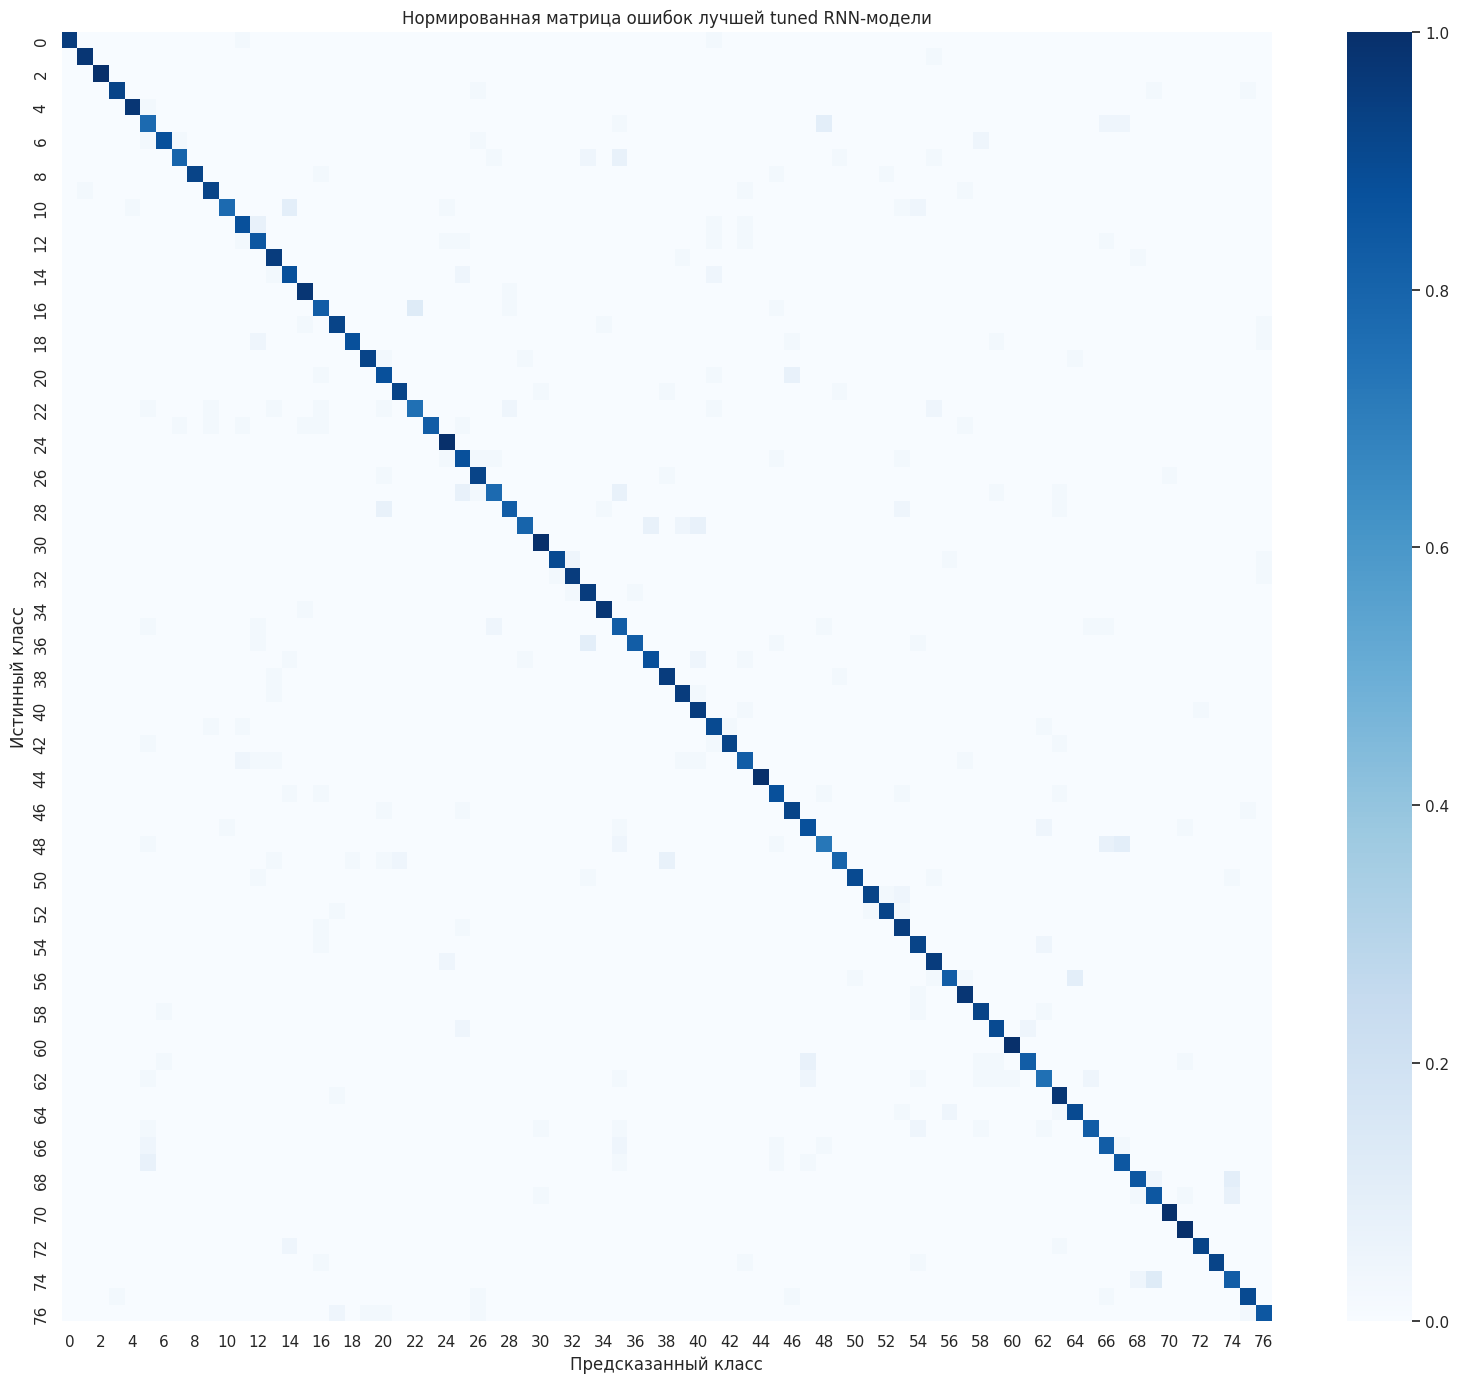

,Артефакт,Путь
0,Baseline summary (Lightning),/home/sukuna/Projects/RNN/artifacts/reports/rnn_lightning_baseline_summary.csv
1,Полный лог всех экспериментов,/home/sukuna/Projects/RNN/artifacts/reports/rnn_experiments_log.csv
2,Summary tuned-конфигураций,/home/sukuna/Projects/RNN/artifacts/reports/rnn_lightning_tuned_summary.csv
3,History лучшей tuned-модели,/home/sukuna/Projects/RNN/artifacts/reports/rnn_lightning_training_history_combo_01_a1_b1_c1_d1.csv
4,Predictions лучшей tuned-модели,/home/sukuna/Projects/RNN/artifacts/reports/rnn_lightning_predictions_combo_01_a1_b1_c1_d1.csv
5,Per-class metrics лучшей tuned-модели,/home/sukuna/Projects/RNN/artifacts/reports/rnn_lightning_per_class_metrics_combo_01_a1_b1_c1_d1.csv
6,Confusion matrix лучшей tuned-модели,/home/sukuna/Projects/RNN/artifacts/reports/rnn_lightning_confusion_matrix_combo_01_a1_b1_c1_d1.png
7,Лучший checkpoint tuned-модели,/home/sukuna/Projects/RNN/artifacts/models/rnn_lightning_best_model_combo_01_a1_b1_c1_d1.ckpt
8,Лучший checkpoint baseline RNN,/home/sukuna/Projects/RNN/artifacts/models/rnn_lightning_baseline_best_model_bilstm_2layer.ckpt
9,Словарь лучшей tuned-модели,/home/sukuna/Projects/RNN/artifacts/models/rnn_lightning_vocab_combo_01_a1_b1_c1_d1.json


In [28]:
rnn_baseline_summary_path = REPORTS_DIR / "rnn_lightning_baseline_summary.csv"
rnn_experiment_log_path = REPORTS_DIR / "rnn_experiments_log.csv"
rnn_tuned_summary_path = REPORTS_DIR / "rnn_lightning_tuned_summary.csv"
rnn_best_tuned_history_path = REPORTS_DIR / f"rnn_lightning_training_history_{best_tuned_rnn['experiment_name']}.csv"
rnn_best_tuned_predictions_path = REPORTS_DIR / f"rnn_lightning_predictions_{best_tuned_rnn['experiment_name']}.csv"
rnn_best_tuned_per_class_path = REPORTS_DIR / f"rnn_lightning_per_class_metrics_{best_tuned_rnn['experiment_name']}.csv"
rnn_best_tuned_confusion_path = REPORTS_DIR / f"rnn_lightning_confusion_matrix_{best_tuned_rnn['experiment_name']}.png"
rnn_best_tuned_ckpt_path = MODELS_DIR / f"rnn_lightning_best_model_{best_tuned_rnn['experiment_name']}.ckpt"
rnn_best_baseline_ckpt_path = MODELS_DIR / f"rnn_lightning_baseline_best_model_{best_baseline_rnn['experiment_name']}.ckpt"
rnn_best_tuned_vocab_path = MODELS_DIR / f"rnn_lightning_vocab_{best_tuned_rnn['experiment_name']}.json"

baseline_result["df"].to_csv(rnn_baseline_summary_path, index=False)
all_experiment_log_df.to_csv(rnn_experiment_log_path, index=False)
series_e_result["df"].to_csv(rnn_tuned_summary_path, index=False)
best_tuned_history_df.to_csv(rnn_best_tuned_history_path, index=False)
best_tuned_predictions_df.to_csv(rnn_best_tuned_predictions_path, index=False)
best_tuned_per_class_df.to_csv(rnn_best_tuned_per_class_path, index=False)

save_confusion_matrix_figure(
    best_tuned_test_output["labels"],
    best_tuned_test_output["preds"],
    label_names,
    rnn_best_tuned_confusion_path,
)

shutil.copy2(best_tuned_rnn["best_model_path"], rnn_best_tuned_ckpt_path)
shutil.copy2(best_baseline_rnn["best_model_path"], rnn_best_baseline_ckpt_path)

dm_for_best_tuned = get_data_module(best_tuned_rnn["config"])
rnn_best_tuned_vocab_path.write_text(json.dumps(dm_for_best_tuned.vocab, indent=2, ensure_ascii=False), encoding="utf-8")

artifact_paths_df = pd.DataFrame(
    {
        "Артефакт": [
            "Baseline summary (Lightning)",
            "Полный лог всех экспериментов",
            "Summary tuned-конфигураций",
            "History лучшей tuned-модели",
            "Predictions лучшей tuned-модели",
            "Per-class metrics лучшей tuned-модели",
            "Confusion matrix лучшей tuned-модели",
            "Лучший checkpoint tuned-модели",
            "Лучший checkpoint baseline RNN",
            "Словарь лучшей tuned-модели",
        ],
        "Путь": [
            str(rnn_baseline_summary_path),
            str(rnn_experiment_log_path),
            str(rnn_tuned_summary_path),
            str(rnn_best_tuned_history_path),
            str(rnn_best_tuned_predictions_path),
            str(rnn_best_tuned_per_class_path),
            str(rnn_best_tuned_confusion_path),
            str(rnn_best_tuned_ckpt_path),
            str(rnn_best_baseline_ckpt_path),
            str(rnn_best_tuned_vocab_path),
        ],
    }
)

display(artifact_paths_df)
